<div style="background-color: rgba(238, 238, 238, 0.6); padding: 20px; max-width: 800px; margin: 40px auto; text-align: center; border-radius: 12px; box-shadow: 0 4px 10px rgba(0,0,0,0.1);">
  <span style="display: block; color: black; font-size: 28px; font-weight: bold; text-shadow: 2px 2px 4px #999999; margin-bottom: 20px;">
    Evaluating Filtering Techniques in Recommender Systems for a Parent-Focused Activity App
  </span>
  <span style="display: block; color: black; font-size: 20px; font-weight: bold; text-shadow: 2px 2px 4px #999999; margin-bottom: 10px;">
    Zygimantas Jakubauskas
  </span>
  <span style="display: block; color: #333; font-size: 16px; font-style: italic;">
    Master's thesis
  </span>
</div>


## Table of contents:
</span>

* [Introduction](#first-bullet)
* [1. Exploratory Data Analysis (EDA)](#second-bullet)
* [2. Data Preparation](#third-bullet)  
* [3. Experiments](#forth-bullet)  
    * [3.1. Memory based Collaborative Filtering](#sixth-bullet)
        * [3.1.1. User-based collaborative filtering](#seventh-bullet)
        * [3.1.2. Item-based collaborative filtering](#eighth-bullet)  
        * [3.1.2. Evaluation of user-based and item-based models](#ninth-bullet)  
    * [3.2. Model based Collaborative Filtering](#1th-bullet)
        * [3.2.1. SVD‑based matrix factorization](#3th-bullet)
    * [3.3. Content-based Filtering](#tenth-bullet) 
    * [3.4. Neural Collaborative Filtering](#4th-bullet) 
        * [3.4.1. Generalized Matrix Factorization](#7th-bullet)
        * [3.4.2. Multi-Layer Perceptron](#5th-bullet)
        * [3.4.3. Neural Matrix Factorization](#6th-bullet)    
* [4. Comparison of RecSys models](#2th-bullet)    
* [5. Testing the models on the unseen data](#11th-bullet)      
* [References](#fifth-bullet)    

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, widgets

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import linear_kernel
from sklearn.preprocessing import normalize

from itertools import product

import tensorflow as tf
from keras.layers import Input, Embedding, Flatten, Dense, Dropout, Concatenate, Dot
from keras.models import Model
from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

from IPython.display import display

from math import sqrt
from typing import Tuple
import scipy.sparse as sp

In [2]:
df_activities = pd.read_csv("activities.csv")

In [3]:
df_activities.head()

,ID,Gender,Age,Activity,Type,Subtype,Format,Environment,Level of Contact,Choice rank,Starting age,Years involved,Still involved?
0,1000,M,22,Soccer,Sport,Ball game,Team,Outdoor,1,Main,11,8,No
1,1000,M,22,Taekwondo,Martial Arts,Martial Arts,Individual,Indoor,1,Side,9,4,No
2,1000,M,22,Swimming,Sport,Water sport,Individual,Indoor,0,Main,8,3,No
3,1000,M,22,Judo,Sport,Combat sport,Individual,Indoor,1,Side,8,1,No
4,1001,F,20,Swimming,Sport,Water sport,Individual,Indoor,1,Main,6,3,No


In [4]:
df_activities.shape

(508, 13)

<span style="color: blue;">

## 1. Exploratory Data Analysis (EDA) <a class="anchor" id="second-bullet"></a>
    
</span>

In [5]:
df_activities.shape

(508, 13)

In [6]:
df_activities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                508 non-null    int64 
 1   Gender            508 non-null    object
 2   Age               508 non-null    int64 
 3   Activity          508 non-null    object
 4   Type              508 non-null    object
 5   Subtype           508 non-null    object
 6   Format            508 non-null    object
 7   Environment       508 non-null    object
 8   Level of Contact  508 non-null    int64 
 9   Choice rank       508 non-null    object
 10  Starting age      508 non-null    int64 
 11  Years involved    508 non-null    int64 
 12  Still involved?   508 non-null    object
dtypes: int64(5), object(8)
memory usage: 51.7+ KB


In [7]:
df_activities.describe(include = "all")

,ID,Gender,Age,Activity,Type,Subtype,Format,Environment,Level of Contact,Choice rank,Starting age,Years involved,Still involved?
count,508.000000,508,508.000000,508,508,508,508,508,508.000000,508,508.000000,508.000000,508
unique,NaN,3,NaN,60,8,22,5,3,NaN,2,NaN,NaN,2
top,NaN,M,NaN,Soccer,Sport,Ball game,Team,Outdoor,NaN,Main,NaN,NaN,No
freq,NaN,279,NaN,71,388,187,270,277,NaN,279,NaN,NaN,270
mean,1089.590551,NaN,21.887795,NaN,NaN,NaN,NaN,NaN,0.604331,NaN,7.946850,7.523622,NaN
std,57.123950,NaN,13.201115,NaN,NaN,NaN,NaN,NaN,0.489476,NaN,3.198732,7.986270,NaN
min,1000.000000,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,1.000000,NaN
25%,1039.000000,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,5.000000,3.000000,NaN
50%,1083.000000,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,7.000000,5.000000,NaN
75%,1138.250000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,10.000000,10.000000,NaN


In [8]:
df_activities.duplicated().value_counts()

False    508
dtype: int64

In [9]:
df_activities.isnull().sum()

ID                  0
Gender              0
Age                 0
Activity            0
Type                0
Subtype             0
Format              0
Environment         0
Level of Contact    0
Choice rank         0
Starting age        0
Years involved      0
Still involved?     0
dtype: int64

In [10]:
df_activities.nunique()

ID                  195
Gender                3
Age                  53
Activity             60
Type                  8
Subtype              22
Format                5
Environment           3
Level of Contact      2
Choice rank           2
Starting age         18
Years involved       35
Still involved?       2
dtype: int64

Text(0.5, 1.0, 'Cardinality')

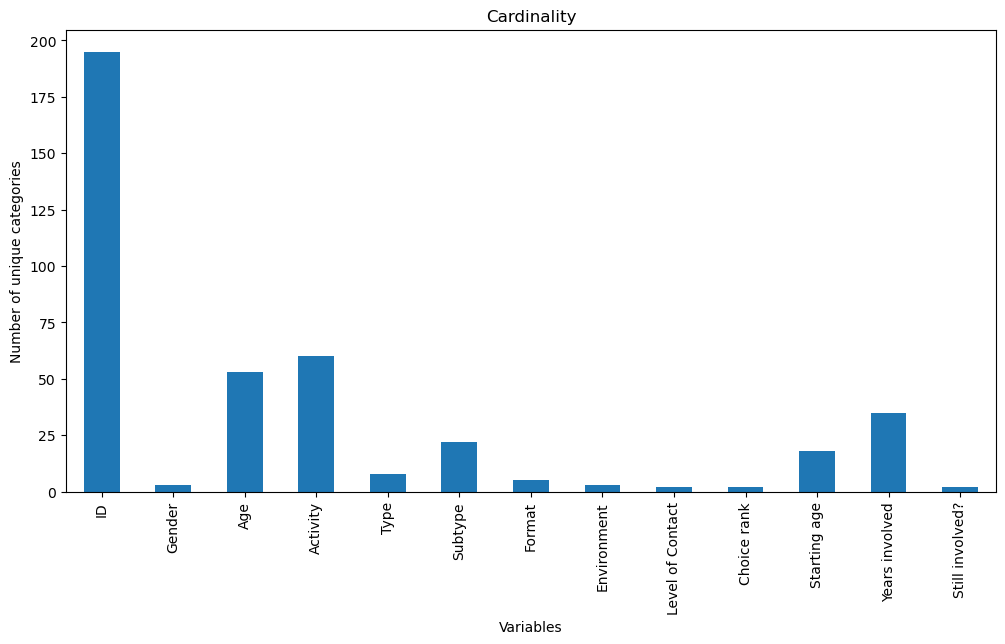

In [11]:
df_activities.nunique().plot.bar(figsize=(12,6))
plt.ylabel("Number of unique categories")
plt.xlabel("Variables")
plt.title("Cardinality")

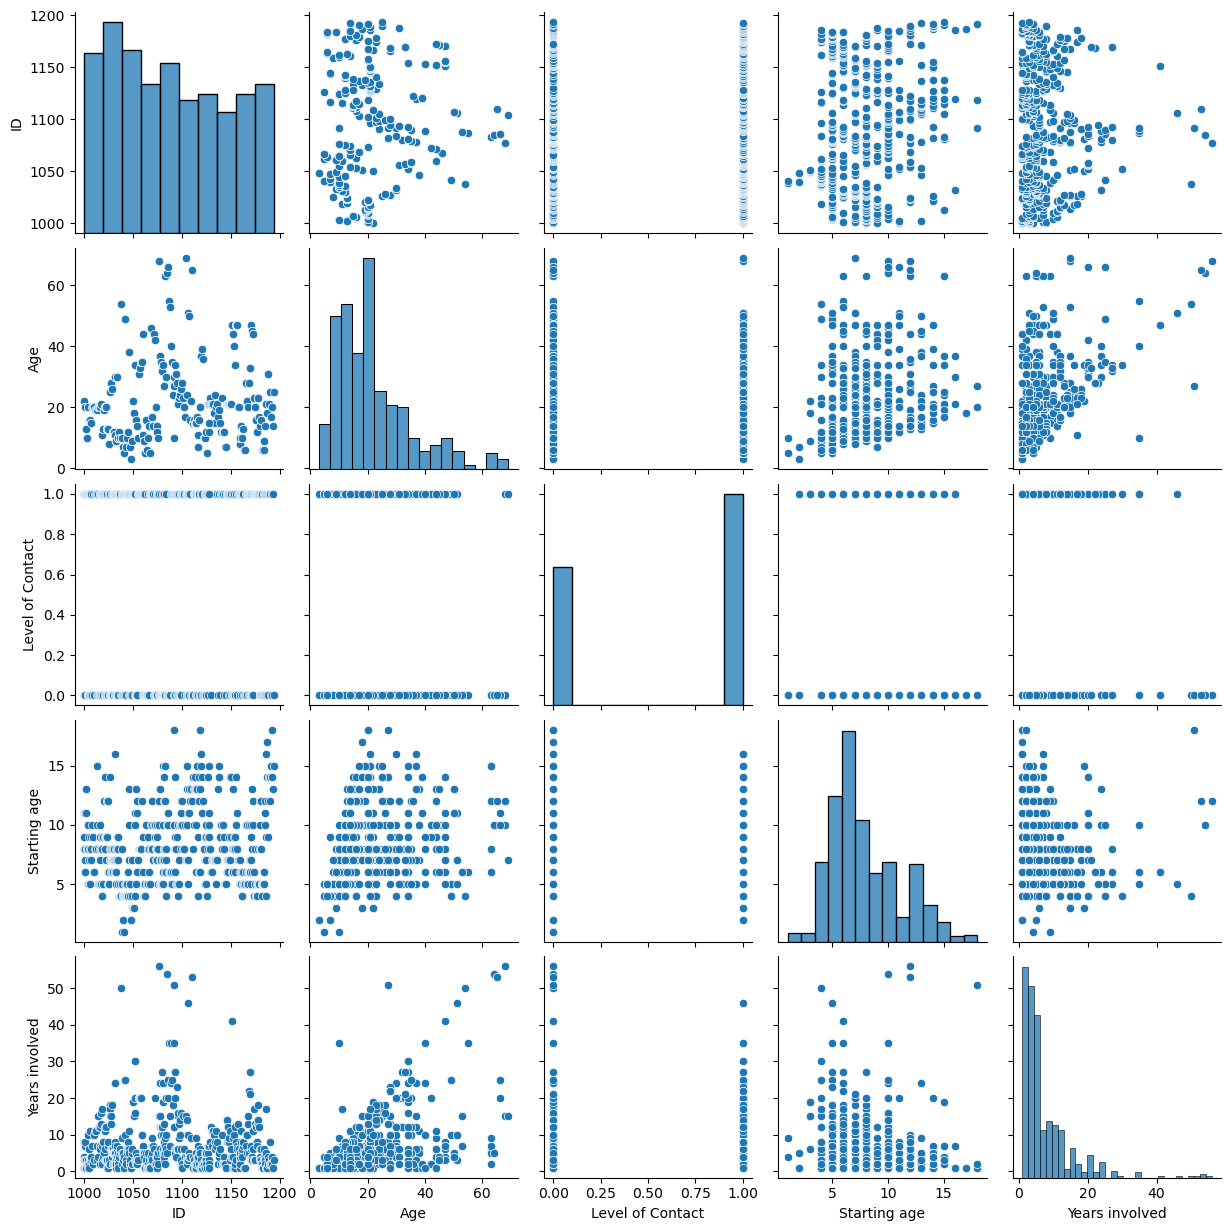

In [12]:
sns.pairplot(df_activities)

In [13]:
df_activities.columns

Index(['ID', 'Gender', 'Age', 'Activity', 'Type', 'Subtype', 'Format',
       'Environment', 'Level of Contact', 'Choice rank', 'Starting age',
       'Years involved', 'Still involved?'],
      dtype='object')

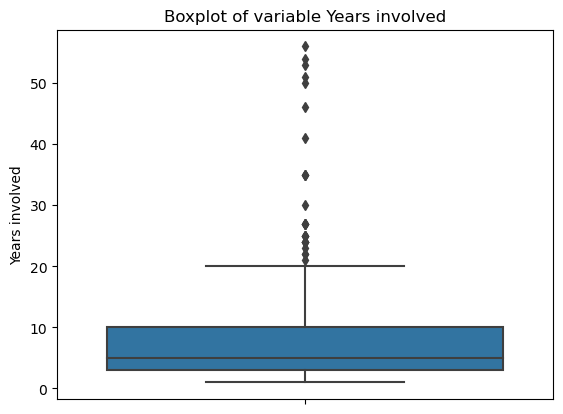

In [14]:
sns.boxplot(y="Years involved", data=df_activities)
plt.title("Boxplot of variable Years involved")
plt.ylabel("Years involved")
plt.show()

In [15]:
df_activities["Activity"].value_counts()

Soccer                  71
GAA football            55
Hurling                 46
Swimming                32
Camogie                 30
Basketball              29
Athletics               20
Chess                   20
GAA Football            19
Tennis                  12
Taekwondo               12
Ballet                  10
Dancing                 10
Badminton                9
Piano                    9
Gymnastics               9
Rugby                    8
Karate                   8
Irish Dancing            7
Scouts                   7
Music                    6
Boxing                   6
Drama                    5
Horse Riding             5
Kick-Boxing              4
Guitar                   4
Judo                     3
Modern Dancing           3
Volleyball               3
Church Youth             3
Table Tennis             3
Fitness                  3
Hockey                   3
Violin                   2
Cello                    2
Contemporary Dancing     2
Cricket                  2
A

Counting and sorting activities. 

In [16]:
activity_counts = (
    df_activities["Activity"]
    .value_counts()
    .sort_values(ascending=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "Activity"}))

Limiting acivities to 25 for plotting reasons for better readability.

In [17]:
top_n = 25
plot_df_activities = activity_counts.head(top_n)

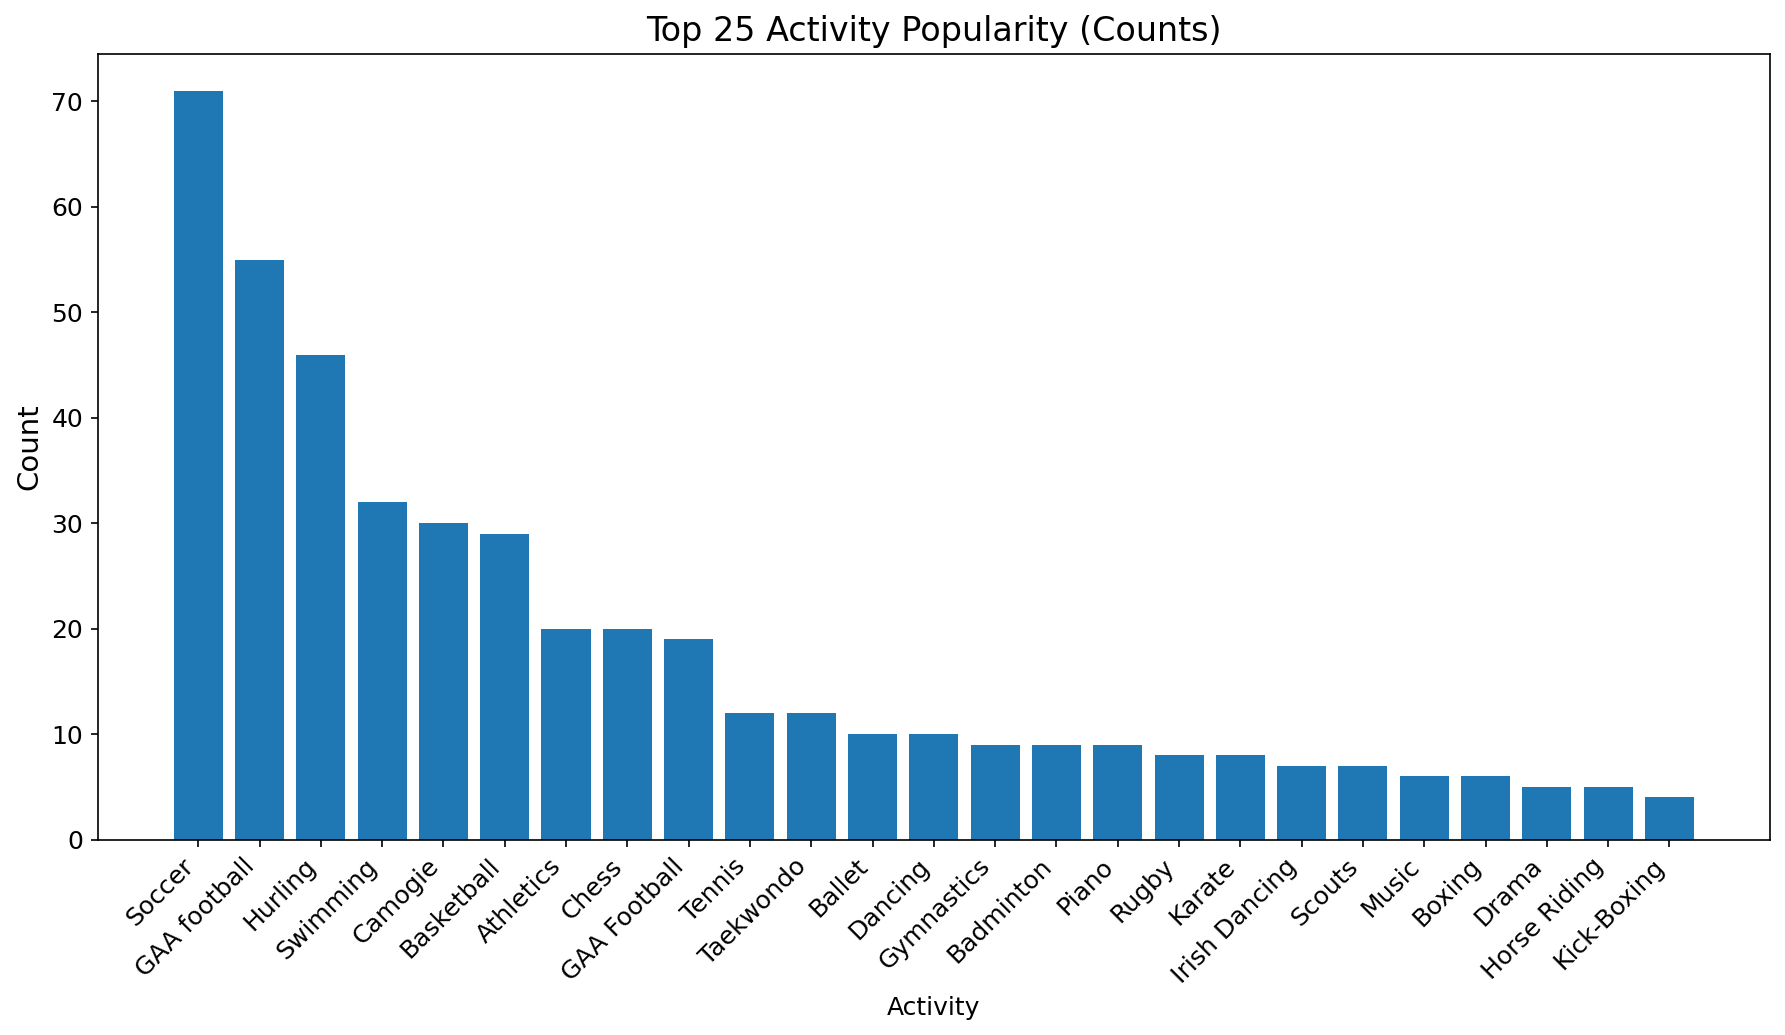

In [18]:
plt.figure(figsize=(12,7), dpi=150)
plt.bar(plot_df_activities["Activity"], plot_df_activities["count"])
plt.xlabel("Activity", fontsize = 12)
plt.ylabel("Count", fontsize = 14)
plt.title(f"Top {min(top_n, len(activity_counts))} Activity Popularity (Counts)", fontsize = 16)
plt.xticks(rotation=45, ha = "right", fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

In [19]:
unique_users = df_activities["ID"].nunique()
unique_activities = df_activities["Activity"].nunique()

In [20]:
print("Number of Users: "+ str(unique_users))
print("Number of Activities: "+str(unique_activities))

Number of Users: 195
Number of Activities: 60


<span style="color: blue;">

## 2. Data Preparation <a class="anchor" id="third-bullet"></a>
    
</span>

Some RecSys like Collaborative Filtering require Ratings to make recommendations. As this dataset doesn’t provide ratings, they can be created. Based on logic, if a person was engaged in a activity for a prolonged period of time, this suggests that he really liked it. Based on variable Years Involved, ratings are given. If activity was done for 1 year, rating is 1, if activity was done for 2 years, rating is 2 and so on. Any activity with more than 9 years in it, gets rating 10.

In [21]:
def ten(years):
    if years > 9:
        return 10
    else:
        return years

df_activities["Rating"] = df_activities["Years involved"].apply(ten)

In [22]:
df_activities.head(20)

,ID,Gender,Age,Activity,Type,Subtype,Format,Environment,Level of Contact,Choice rank,Starting age,Years involved,Still involved?,Rating
0,1000,M,22,Soccer,Sport,Ball game,Team,Outdoor,1,Main,11,8,No,8
1,1000,M,22,Taekwondo,Martial Arts,Martial Arts,Individual,Indoor,1,Side,9,4,No,4
2,1000,M,22,Swimming,Sport,Water sport,Individual,Indoor,0,Main,8,3,No,3
3,1000,M,22,Judo,Sport,Combat sport,Individual,Indoor,1,Side,8,1,No,1
4,1001,F,20,Swimming,Sport,Water sport,Individual,Indoor,1,Main,6,3,No,3
5,1001,F,20,Taekwondo,Martial Arts,Martial Arts,Individual,Indoor,1,Side,7,3,No,3
6,1001,F,20,Scouts,Community,Social skills,Social,Mixed,0,Side,8,3,No,3
7,1001,F,20,GAA football,Sport,Ball game,Team,Outdoor,1,Main,11,7,No,7
8,1001,F,20,Camogie,Sport,Stick and Ball,Team,Outdoor,1,Main,11,8,No,8
9,1001,F,20,Judo,Sport,Combat sport,Individual,Indoor,1,Side,6,1,No,1


In [23]:
df_activities["Participated"] = 1

In [24]:
agg_df = df_activities.pivot_table(index=["ID", "Gender", "Age"],
                          columns="Activity",
                          values="Participated",
                          aggfunc="max",
                          fill_value=0).reset_index()

In [25]:
agg_df.head()

Activity,ID,Gender,Age,Acrobatics,American Football,Archery,Art,Athletics,Badminton,Ballet,...,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Weight Lifting,Wrestling
0,1000,M,22,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
1,1001,F,20,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
2,1002,F,13,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1003,F,10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1003,M,10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
user_item_matrix = df_activities.pivot_table(
    index="ID",
    columns="Activity",
    values="Rating",
    aggfunc="mean",
    fill_value=0)

In [27]:
user_item_matrix.head()

Activity,Acrobatics,American Football,Archery,Art,Athletics,Badminton,Ballet,Basketball,Boxing,Camogie,...,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Weight Lifting,Wrestling
ID,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,3,0,4,0,0,0,0,0,0,0
1001,0,0,0,0,0,0,0,0,0,8,...,3,0,3,0,0,0,0,0,0,0
1002,0,0,0,0,0,0,0,3,0,1,...,0,0,0,0,0,0,0,0,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,1,0,0,10,...,3,0,0,0,0,0,0,0,0,0


In [28]:
user_user_array = cosine_similarity(user_item_matrix.values)
user_user_array 

array([[1.        , 0.19529534, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.19529534, 1.        , 0.38087754, ..., 0.39300423, 0.        ,
        0.        ],
       [0.        , 0.38087754, 1.        , ..., 0.20100756, 0.        ,
        0.        ],
       ...,
       [0.        , 0.39300423, 0.20100756, ..., 1.        , 0.66666667,
        0.33333333],
       [0.        , 0.        , 0.        , ..., 0.66666667, 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.33333333, 0.        ,
        1.        ]])

In [29]:
user_user_matrix = pd.DataFrame(
    user_user_array,
    index = user_item_matrix.index,   
    columns = user_item_matrix.index)

In [30]:
user_user_matrix.head()

ID,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,1185,1186,1187,1188,1189,1190,1191,1192,1193,1194
ID,,,,,,,,,,,,,,,,,,,,,
1000,1.000000,0.195295,0.000000,0.000000,0.063529,0.072075,0.980521,0.938343,0.0,0.0,...,0.000000,0.751248,0.0,0.141421,0.0,0.795046,0.0,0.000000,0.000000,0.0
1001,0.195295,1.000000,0.380878,0.416844,0.947430,0.950124,0.158181,0.276196,0.0,0.0,...,0.000000,0.000000,0.0,0.715581,0.0,0.138948,0.0,0.393004,0.000000,0.0
1002,0.000000,0.380878,1.000000,0.213201,0.403814,0.412325,0.000000,0.000000,0.0,0.0,...,0.671871,0.000000,0.0,0.269680,0.0,0.284268,0.0,0.201008,0.000000,0.0
1003,0.000000,0.416844,0.213201,1.000000,0.473514,0.483494,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.166667,0.0,0.942809,0.707107,0.0
1004,0.063529,0.947430,0.403814,0.473514,1.000000,0.984446,0.071874,0.094124,0.0,0.0,...,0.000000,0.000000,0.0,0.688796,0.0,0.157838,0.0,0.446433,0.000000,0.0


In [31]:
item_item_matrix = cosine_similarity(user_item_matrix.values.T)

In [32]:
item_item_array = cosine_similarity(item_item_matrix)
item_item_array 

array([[1.        , 0.        , 0.        , ..., 0.00267868, 0.        ,
        0.02581644],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00267868, 0.        , 0.        , ..., 1.        , 0.        ,
        0.01037174],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.02581644, 0.        , 0.        , ..., 0.01037174, 0.        ,
        1.        ]])

In [33]:
item_item_matrix = pd.DataFrame(
    item_item_matrix,
    index = user_item_matrix.columns,
    columns = user_item_matrix.columns)

In [34]:
item_item_matrix.head()

Activity,Acrobatics,American Football,Archery,Art,Athletics,Badminton,Ballet,Basketball,Boxing,Camogie,...,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Weight Lifting,Wrestling
Activity,,,,,,,,,,,,,,,,,,,,,
Acrobatics,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.036298,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
American Football,0.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.457869,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
Archery,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
Art,0.0,0.0,0.0,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
Athletics,0.0,0.0,0.0,0.0,1.0,0.105927,0.010789,0.211441,0.0,0.300900,...,0.103154,0.0,0.000000,0.0,0.0,0.0,0.257455,0.0,0.0,0.0


<span style="color: blue;">

## 3. Experiments <a class="anchor" id="forth-bullet"></a>
    
</span>

<span style="color: blue;">

### 3.1. Memory based Collaborative Filtering <a class="anchor" id="sixth-bullet"></a>
    
</span>

Item-Item Collaborative Filtering: “Users who liked this item also liked …”

User-Item Collaborative Filtering: “Users who are similar to you also liked …”

<span style="color: blue;">

#### 3.1.1. User-based Collaborative FIltering <a class="anchor" id="seventh-bullet"></a>
    
</span>

Starting with the most common approach in recommender systems - User-based CF. This function defines top similar users (5 of them).

In [35]:
def top_similar_users(id, k = 5):
    similar_users = user_user_matrix.loc[id].drop(id)           
    return similar_users.nlargest(k).index.tolist()

In [36]:
print("Top 5 similar users for user 1000:", top_similar_users(1000, 6))

Top 5 similar users for user 1000: [1006, 1121, 1007, 1011, 1012, 1104]


In [37]:
top_5 = [1000, 1006, 1121, 1007, 1011, 1012, 1104]

In [38]:
similar_users_df = agg_df[agg_df["ID"].isin(top_5) ]

In [39]:
similar_users_df.head()

Activity,ID,Gender,Age,Acrobatics,American Football,Archery,Art,Athletics,Badminton,Ballet,...,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Weight Lifting,Wrestling
0,1000,M,22,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
7,1006,M,16,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
8,1007,F,15,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
12,1011,F,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,1012,F,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
top5_similarity_matrix = user_user_matrix.loc[top_5, top_5]

In [41]:
top5_similarity_matrix.head(6)

ID,1000,1006,1121,1007,1011,1012,1104
ID,,,,,,,
1000,1.000000,0.980521,0.942809,0.938343,0.843274,0.843274,0.843274
1006,0.980521,1.000000,0.920000,0.893991,0.894427,0.894427,0.894427
1121,0.942809,0.920000,1.000000,0.838116,0.894427,0.894427,0.894427
1007,0.938343,0.893991,0.838116,1.000000,0.624695,0.624695,0.624695
1011,0.843274,0.894427,0.894427,0.624695,1.000000,1.000000,1.000000
1012,0.843274,0.894427,0.894427,0.624695,1.000000,1.000000,1.000000


In [42]:
filtered = similar_users_df.loc[:, (similar_users_df != 0).any(axis = 0)]

In [43]:
filtered.head()

Activity,ID,Gender,Age,Judo,Soccer,Swimming,Taekwondo
0,1000,M,22,1,1,1,1
7,1006,M,16,0,1,1,1
8,1007,F,15,0,1,1,1
12,1011,F,19,0,1,0,0
13,1012,F,19,0,1,0,0


#### different way

In [44]:

R = (df_activities
     .pivot_table(index="ID", columns="Activity", values="Rating",
                  aggfunc="mean", fill_value=0)
     .sort_index())

rated_mask = R.gt(0)
user_means = R.where(rated_mask).mean(axis=1).fillna(0)        
R_centered = (R.sub(user_means, axis=0)).where(rated_mask, 0)  

In [45]:
U_sim = pd.DataFrame(cosine_similarity(R_centered.values),
                     index=R.index, columns=R.index)

In [46]:
def recommend_for_user(user_id, n_recs=10, k_neighbors=20, min_sim=0.0):
    
    if user_id not in R.index:
        
        pop = (df_activities.groupby("Activity")["Rating"]
               .count().sort_values(ascending=False).index[:n_recs])
        return pd.DataFrame({"Activity": pop, "score": np.nan, "why": "popular"})
    
    sims = U_sim.loc[user_id].drop(user_id)
    sims = sims[sims >= min_sim].sort_values(ascending=False).head(k_neighbors)
    if sims.empty:
        pop = (df_activities.groupby("Activity")["Rating"]
               .count().sort_values(ascending=False).index[:n_recs])
        return pd.DataFrame({"Activity": pop, "score": np.nan, "why": "popular"})
    
    nbr_centered = R_centered.loc[sims.index]            
    w = sims.values.reshape(-1, 1)                       
    weighted = nbr_centered.values * w                   
    den = np.abs(w).sum()
    pred_centered = weighted.sum(axis=0) / den if den > 0 else np.zeros(R.shape[1])
    preds = pd.Series(pred_centered, index=R.columns) + user_means.loc[user_id]

    
    preds = preds.mask(rated_mask.loc[user_id], other=-np.inf)

    top = preds.sort_values(ascending=False).head(n_recs)
    return pd.DataFrame({"Activity": top.index, "score": top.values, "why": "user-based CF"})


In [47]:
def _predict_single(user_id, item, k_neighbors=20, min_sim=0.0):
    sims = U_sim.loc[user_id].drop(user_id)
    sims = sims[sims >= min_sim].sort_values(ascending=False).head(k_neighbors)
    if sims.empty:
        return float(user_means.loc[user_id])
    nbr_centered = R_centered.loc[sims.index, item].values  # (k,)
    w = sims.values
    den = np.abs(w).sum()
    pred_c = (nbr_centered @ w) / den if den > 0 else 0.0
    return float(pred_c + user_means.loc[user_id])

In [48]:
def evaluate_full_metrics(k_neighbors=20, min_sim=0.0, pos_thresh=0.6, cls_thresh=None, seed=42):
    
    rng = np.random.default_rng(seed)
    y_true, y_score = [], []

    for uid, row in R.iterrows():
        rated_items = row[row > 0]
        if len(rated_items) < 2:
            continue
        hold_item = rated_items.index[rng.integers(0, len(rated_items))]
        true_rating = float(rated_items[hold_item])

        backup_val = R.loc[uid, hold_item]
        backup_mask = rated_mask.loc[uid, hold_item]
        R.loc[uid, hold_item] = 0
        rated_mask.loc[uid, hold_item] = False
        user_means.loc[uid] = R.loc[uid].where(rated_mask.loc[uid]).mean()
        if pd.isna(user_means.loc[uid]): user_means.loc[uid] = 0.0
        R_centered.loc[uid] = (R.loc[uid] - user_means.loc[uid]).where(rated_mask.loc[uid], 0)

        pred_rating = _predict_single(uid, hold_item, k_neighbors=k_neighbors, min_sim=min_sim)

        R.loc[uid, hold_item] = backup_val
        rated_mask.loc[uid, hold_item] = backup_mask
        user_means.loc[uid] = R.loc[uid].where(rated_mask.loc[uid]).mean()
        if pd.isna(user_means.loc[uid]): user_means.loc[uid] = 0.0
        R_centered.loc[uid] = (R.loc[uid] - user_means.loc[uid]).where(rated_mask.loc[uid], 0)

        y_true.append(true_rating / 10.0)
        y_score.append(max(0.0, min(1.0, pred_rating / 10.0)))

    if not y_true:
        return {"RMSE": np.nan, "MAE": np.nan, "AUC": np.nan,
                "Accuracy": np.nan, "Precision": np.nan,
                "Recall": np.nan, "F1": np.nan}

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    mae  = mean_absolute_error(y_true, y_score)
    rmse = mean_squared_error(y_true, y_score, squared=False)

    y_true_bin = (y_true >= pos_thresh).astype(int)
    if cls_thresh is None:
        cls_thresh = pos_thresh
    y_pred_bin = (y_score >= cls_thresh).astype(int)

    try:
        auc = roc_auc_score(y_true_bin, y_score)
    except ValueError:
        auc = np.nan

    acc = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

    return {"RMSE": float(rmse), "MAE": float(mae), "AUC": float(auc),
            "Accuracy": float(acc), "Precision": float(prec),
            "Recall": float(rec), "F1": float(f1)}


In [49]:
def recommend_for_user(user_id, n_recs=10, k_neighbors=20, min_sim=0.0):
    
    if user_id not in R.index:

        pop = (df_activities.groupby("Activity")["Rating"]
               .count().sort_values(ascending=False).index[:n_recs])
        return pd.DataFrame({"Activity": pop, "score": np.nan, "why": "popular"})
    
    sims = U_sim.loc[user_id].drop(user_id)
    sims = sims[sims >= min_sim].sort_values(ascending=False).head(k_neighbors)
    if sims.empty:
        pop = (df_activities.groupby("Activity")["Rating"]
               .count().sort_values(ascending=False).index[:n_recs])
        return pd.DataFrame({"Activity": pop, "score": np.nan, "why": "popular"})
    
    nbr_centered = R_centered.loc[sims.index]
    w = sims.values.reshape(-1, 1)
    weighted = nbr_centered.values * w
    denom = np.abs(w).sum()
    pred_centered = weighted.sum(axis=0) / denom if denom > 0 else np.zeros(R.shape[1])
    preds = pd.Series(pred_centered, index=R.columns) + user_means.loc[user_id]

    preds = preds.mask(rated_mask.loc[user_id], other=-np.inf)

    top = preds.sort_values(ascending=False).head(n_recs)
    return pd.DataFrame({"Activity": top.index, "score": top.values, "why": "user-based CF"})


In [50]:
recs = recommend_for_user(1000, n_recs=10, k_neighbors=20, min_sim=0.1)
print(recs)


            Activity     score            why
0            Camogie  4.100527  user-based CF
1              Chess  4.066776  user-based CF
2       GAA Football  4.059306  user-based CF
3            Kung-Fu  4.000000  user-based CF
4         Gymnastics  4.000000  user-based CF
5           Handball  4.000000  user-based CF
6             Hockey  4.000000  user-based CF
7       Horse Riding  4.000000  user-based CF
8  American Football  4.000000  user-based CF
9      Irish Dancing  4.000000  user-based CF


In [51]:
metrics = evaluate_full_metrics(k_neighbors=20, min_sim=0.1, pos_thresh=0.6, cls_thresh=0.6)
print(metrics)

{'RMSE': 0.2197978778830788, 'MAE': 0.13851200252194756, 'AUC': 0.8997276132107593, 'Accuracy': 0.8451612903225807, 'Precision': 0.8088235294117647, 'Recall': 0.8333333333333334, 'F1': 0.8208955223880597}


#### hypertuning

In [52]:
k_values = [5, 10, 20, 30, 50]
min_sims = [0.0, 0.1, 0.2, 0.3]
pos_thresholds = [0.5, 0.6, 0.7]

results = []

for k, ms, pt in product(k_values, min_sims, pos_thresholds):
    metrics = evaluate_full_metrics(
        k_neighbors=k,
        min_sim=ms,
        pos_thresh=pt,
        cls_thresh=pt  
    )
    results.append({
        "k_neighbors": k,
        "min_sim": ms,
        "pos_thresh": pt,
        **metrics
    })

results_df = pd.DataFrame(results)

best_by_rmse = results_df.sort_values("RMSE").head(10)
best_by_auc  = results_df.sort_values("AUC", ascending=False).head(10)


print("Top 10 configs (by RMSE):")
print(best_by_rmse)

print("\nTop 10 configs (by AUC):")
print(best_by_auc)




Top 10 configs (by RMSE):
   k_neighbors  min_sim  pos_thresh      RMSE       MAE       AUC  Accuracy  \
6            5      0.2         0.5  0.208992  0.130354  0.873745  0.787097   
7            5      0.2         0.6  0.208992  0.130354  0.906963  0.845161   
8            5      0.2         0.7  0.208992  0.130354  0.901084  0.838710   
0            5      0.0         0.5  0.209725  0.131075  0.872908  0.787097   
1            5      0.0         0.6  0.209725  0.131075  0.907218  0.845161   
2            5      0.0         0.7  0.209725  0.131075  0.900462  0.832258   
3            5      0.1         0.5  0.210073  0.131451  0.872406  0.787097   
4            5      0.1         0.6  0.210073  0.131451  0.907729  0.845161   
5            5      0.1         0.7  0.210073  0.131451  0.900995  0.832258   
9            5      0.3         0.5  0.212150  0.132741  0.869227  0.780645   

   Precision    Recall        F1  
6   0.812500  0.783133  0.797546  
7   0.808824  0.833333  0.820896  

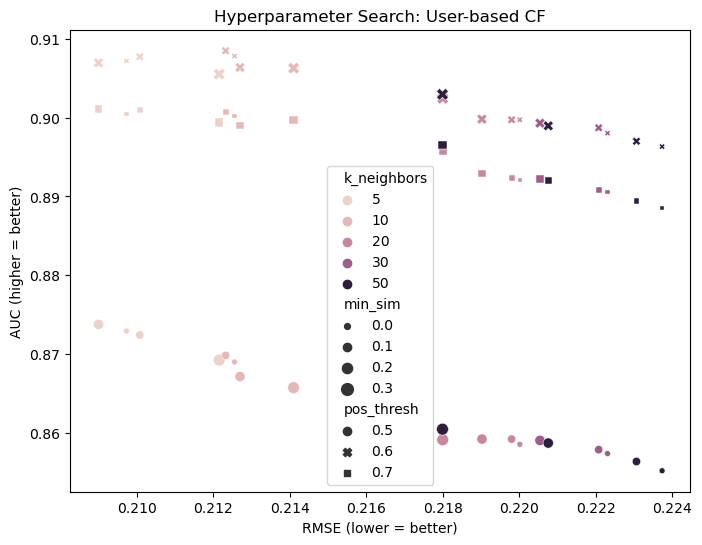

In [53]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=results_df, x="RMSE", y="AUC", hue="k_neighbors", style="pos_thresh", size="min_sim")
plt.title("Hyperparameter Search: User-based CF")
plt.xlabel("RMSE (lower = better)")
plt.ylabel("AUC (higher = better)")
plt.show()

In [54]:
best_by_rmse = results_df.sort_values("RMSE").head(10)
best_by_auc  = results_df.sort_values("AUC", ascending=False).head(10)

In [55]:
best_by_rmse["Rank_by"] = "RMSE"
best_by_auc["Rank_by"]  = "AUC"

comparison = pd.concat([best_by_rmse, best_by_auc], ignore_index=True)

cols = ["Rank_by", "k_neighbors", "min_sim", "pos_thresh",
        "RMSE", "MAE", "AUC", "Accuracy",
        "Precision", "Recall", "F1"]
comparison = comparison[cols]

comparison = comparison.sort_values(["Rank_by", "RMSE", "AUC"], ascending=[True, True, False])

display(comparison)

def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

display(comparison.style.apply(highlight_best, subset=["F1"]))




,Rank_by,k_neighbors,min_sim,pos_thresh,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1
14,AUC,5,0.2,0.6,0.208992,0.130354,0.906963,0.845161,0.808824,0.833333,0.820896
13,AUC,5,0.0,0.6,0.209725,0.131075,0.907218,0.845161,0.808824,0.833333,0.820896
12,AUC,5,0.1,0.6,0.210073,0.131451,0.907729,0.845161,0.808824,0.833333,0.820896
17,AUC,5,0.3,0.6,0.212150,0.132741,0.905516,0.845161,0.808824,0.833333,0.820896
10,AUC,10,0.1,0.6,0.212320,0.133138,0.908495,0.845161,0.808824,0.833333,0.820896
11,AUC,10,0.0,0.6,0.212549,0.133194,0.907814,0.845161,0.808824,0.833333,0.820896
15,AUC,10,0.2,0.6,0.212694,0.133227,0.906367,0.845161,0.808824,0.833333,0.820896
16,AUC,10,0.3,0.6,0.214096,0.134024,0.906282,0.845161,0.808824,0.833333,0.820896
18,AUC,50,0.3,0.6,0.217990,0.136663,0.902962,0.845161,0.808824,0.833333,0.820896
19,AUC,30,0.3,0.6,0.217990,0.136663,0.902962,0.845161,0.808824,0.833333,0.820896


,Rank_by,k_neighbors,min_sim,pos_thresh,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1
14,AUC,5,0.200000,0.600000,0.208992,0.130354,0.906963,0.845161,0.808824,0.833333,0.820896
13,AUC,5,0.000000,0.600000,0.209725,0.131075,0.907218,0.845161,0.808824,0.833333,0.820896
12,AUC,5,0.100000,0.600000,0.210073,0.131451,0.907729,0.845161,0.808824,0.833333,0.820896
17,AUC,5,0.300000,0.600000,0.212150,0.132741,0.905516,0.845161,0.808824,0.833333,0.820896
10,AUC,10,0.100000,0.600000,0.212320,0.133138,0.908495,0.845161,0.808824,0.833333,0.820896
11,AUC,10,0.000000,0.600000,0.212549,0.133194,0.907814,0.845161,0.808824,0.833333,0.820896
15,AUC,10,0.200000,0.600000,0.212694,0.133227,0.906367,0.845161,0.808824,0.833333,0.820896
16,AUC,10,0.300000,0.600000,0.214096,0.134024,0.906282,0.845161,0.808824,0.833333,0.820896
18,AUC,50,0.300000,0.600000,0.217990,0.136663,0.902962,0.845161,0.808824,0.833333,0.820896
19,AUC,30,0.300000,0.600000,0.217990,0.136663,0.902962,0.845161,0.808824,0.833333,0.820896


<span style="color: blue;">

#### 3.1.2. Item-based Collaborative FIltering <a class="anchor" id="eighth-bullet"></a>
    
</span>

In [56]:
def nearest_neighbors(sim_df, activity, k = 5):
    similar_activities = sim_df.loc[activity].drop(activity)
    return similar_activities.nlargest(k)

In [57]:
print("Top 5 items like Soccer:")
print(nearest_neighbors(item_item_matrix, "Soccer", k = 5))

Top 5 items like Soccer:
Activity
Hurling         0.339403
GAA football    0.314876
Karate          0.283001
Chess           0.257719
Tennis          0.224455
Name: Soccer, dtype: float64


<span style="color: blue;">

#### 3.1.3. Evaluation of user-based and item-based models <a class="anchor" id="ninth-bullet"></a>
    
</span>

Splitting the dataset into training and testing subsets, so you recommender systems can be evaluated.

In [58]:
train_df, test_df = train_test_split(df_activities, test_size=0.2, random_state=42)

Training dataframe is converted into user-item matrix.

In [59]:
train_matrix = train_df.pivot_table(
    index="ID",
    columns="Activity",
    values="Rating",
    aggfunc="mean",
    fill_value=0)

In [60]:
train_matrix.head()

Activity,Acrobatics,American Football,Art,Athletics,Badminton,Ballet,Basketball,Boxing,Camogie,Cello,...,Street Dancing,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Wrestling
ID,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,0,0,0,0,0,0
1001,0,0,0,0,0,0,0,0,8,0,...,0,3,0,3,0,0,0,0,0,0
1002,0,0,0,0,0,0,3,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,1,0,0,10,0,...,0,3,0,0,0,0,0,0,0,0


Similarly test matrix is created.

In [61]:
test_matrix = test_df.pivot_table(
    index="ID", columns="Activity",
    values="Rating", aggfunc="mean", fill_value=0
).reindex(
    index=train_matrix.index,
    columns=train_matrix.columns,
    fill_value=0)

Scaling the ratings so they are in 0-1 scale, so all the metrics can be compared.

In [62]:
rmin = train_df["Rating"].min()
rmax = train_df["Rating"].max()
rng  = max(1e-8, (rmax - rmin))

In [63]:
def scale_dense(M):
    M = M.copy().astype(float)
    mask = M != 0                
    M[mask] = (M[mask] - rmin) / rng
    return M

Applying the newly created function to the matrix, with ratings now normalised in a 0-1 range.

In [64]:
train_scaled = pd.DataFrame(scale_dense(train_matrix.values),
                            index=train_matrix.index, columns=train_matrix.columns)
test_scaled  = pd.DataFrame(scale_dense(test_matrix.values),
                            index=test_matrix.index,  columns=test_matrix.columns)

Computing the similarity matrices

In [65]:
user_distance = pairwise_distances(train_scaled.values, metric="cosine")
user_similarity = 1 - user_distance
item_distance = pairwise_distances(train_scaled.values.T, metric="cosine")
item_similarity = 1 - item_distance

Overwriting all diagonal values with 0.0 (they are all egual 1 at the start), so recomennder systems don't look for similarity with themselves.

In [66]:
np.fill_diagonal(user_similarity, 0.0)
np.fill_diagonal(item_similarity, 0.0)

Defining functions for the recommender system. One of each for user-user and item-item.

In [67]:
def predict_user_based(ratings, user_sim, k=None):
    R = ratings
    rated_counts = (R != 0).sum(axis=1, keepdims=True)
    mean_user = np.divide(R.sum(axis=1, keepdims=True), rated_counts,
                          out=np.zeros_like(rated_counts, dtype=float),
                          where=rated_counts != 0)
    dev = np.where(R != 0, R - mean_user, 0.0)

    S = user_sim.copy()
    if k is not None and k < S.shape[1]:
        
        idx = np.argpartition(S, -k, axis=1)[:, :-k]
        S[np.arange(S.shape[0])[:, None], idx] = 0.0

    denom = np.abs(S).sum(axis=1, keepdims=True) + 1e-8
    pred = mean_user + S.dot(dev) / denom
    return np.clip(pred, 0.0, 1.0)

def predict_item_based(ratings, item_sim, k=None):
    R = ratings
    S = item_sim.copy()
    if k is not None and k < S.shape[1]:
        idx = np.argpartition(S, -k, axis=1)[:, :-k]
        S[np.arange(S.shape[0])[:, None], idx] = 0.0

    denom = np.abs(S).sum(axis=1) + 1e-8
    pred = R.dot(S) / denom[np.newaxis, :]
    return np.clip(pred, 0.0, 1.0)

Defining a number of nearest neighbors as a starting point.

In [68]:
TOPK = 20

Creating prediction matrixes next.

In [69]:
user_pred = predict_user_based(train_scaled.values, user_similarity, k=TOPK)
item_pred = predict_item_based(train_scaled.values, item_similarity, k=TOPK)

Transforming numpy matrixes into pandas dataframes.

In [70]:
user_pred_df = pd.DataFrame(user_pred, index = train_scaled.index, columns = train_scaled.columns)
item_pred_df = pd.DataFrame(item_pred, index = train_scaled.index, columns = train_scaled.columns)

In [71]:
user_pred_df.head()

Activity,Acrobatics,American Football,Art,Athletics,Badminton,Ballet,Basketball,Boxing,Camogie,Cello,...,Street Dancing,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Wrestling
ID,,,,,,,,,,,,,,,,,,,,,
1000,0.333333,0.333333,0.333333,0.333333,0.322324,0.333333,0.333333,0.333333,0.347795,0.333333,...,0.355351,0.308288,0.333333,0.338982,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
1001,0.422222,0.422222,0.422222,0.390490,0.422222,0.422222,0.392900,0.422222,0.494546,0.422222,...,0.422222,0.386092,0.422222,0.422222,0.422222,0.422222,0.422222,0.422222,0.422222,0.422222
1002,0.222222,0.222222,0.222222,0.211325,0.222222,0.222222,0.317822,0.222222,0.222222,0.222222,...,0.222222,0.168498,0.222222,0.222222,0.208763,0.222222,0.222222,0.222222,0.222222,0.222222
1003,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.098887,0.105189,0.111111,...,0.111111,0.103639,0.111111,0.111111,0.082382,0.111111,0.111111,0.111111,0.111111,0.111111
1004,0.583333,0.583333,0.583333,0.551238,0.583333,0.583333,0.553676,0.583333,0.650412,0.583333,...,0.583333,0.558203,0.583333,0.572156,0.583333,0.583333,0.583333,0.583333,0.583333,0.583333


In [72]:
item_pred_df.head()

Activity,Acrobatics,American Football,Art,Athletics,Badminton,Ballet,Basketball,Boxing,Camogie,Cello,...,Street Dancing,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Wrestling
ID,,,,,,,,,,,,,,,,,,,,,
1000,0.000000,0.333333,0.0,0.000000,0.003455,0.000000,0.000000,0.000000,0.003908,0.0,...,0.135752,0.010311,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
1001,0.000000,0.222222,0.0,0.249036,0.002303,0.019758,0.077492,0.240814,0.179915,0.0,...,0.090502,0.131716,0.0,0.057597,0.019412,0.222222,0.177072,0.0,0.777778,0.127020
1002,0.000000,0.000000,0.0,0.029356,0.000000,0.000000,0.000000,0.000000,0.002257,0.0,...,0.020329,0.018819,0.0,0.000000,0.026623,0.000000,0.000000,0.0,0.000000,0.000000
1003,0.006217,0.000000,0.0,0.021100,0.000000,0.000000,0.010205,0.081146,0.028106,0.0,...,0.000000,0.025425,0.0,0.002142,0.006541,0.000000,0.000000,0.0,0.000000,0.000000
1004,0.000000,0.000000,0.0,0.335775,0.000000,0.024622,0.110663,0.361221,0.256206,0.0,...,0.000000,0.178671,0.0,0.059606,0.032156,0.000000,0.222230,0.0,1.000000,0.163312


Creating evaluation function for rating prediction errors.

In [73]:
def compute_errors(prediction: np.ndarray, ground_truth: np.ndarray):
    mask = ground_truth != 0
    y_pred = prediction[mask]
    y_true = ground_truth[mask]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae

Evaluating recommender predictions. Compares user-based CF predictions (user_pred) with the true test ratings (test_scaled.values). Same is done item-based predictions.

In [74]:
rmse_user, mae_user = compute_errors(user_pred, test_scaled.values)
rmse_item, mae_item = compute_errors(item_pred, test_scaled.values)

In [75]:
print(f"User-based CF → RMSE: {rmse_user:.4f}, MAE: {mae_user:.4f}")

print(f"Item-based CF → RMSE: {rmse_item:.4f}, MAE: {mae_item:.4f}")

User-based CF → RMSE: 0.3542, MAE: 0.2505
Item-based CF → RMSE: 0.5706, MAE: 0.4736


Displaying calculated results in a table.

In [76]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE"],
    "User-based CF": [
        rmse_user,
        mae_user,],
    
    "Item-based CF": [
        rmse_item,
        mae_item,],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Comparison of regression metrics across RecSys models")
    .hide(axis="index"))

styled_table

Model,RMSE,MAE
User-based CF,0.354186,0.250467
Item-based CF,0.570564,0.473637


With MAE and RMSE calculated, array is created for more detailed evaluation metrics.

In [77]:
mask = test_scaled.values != 0
y_score_user = user_pred[mask]   
y_score_item = item_pred[mask]
y_true_cont  = test_scaled.values[mask] 

Defining the cut-off point for positive and negative ratings. Above 0.5 is labelled positive, below 0.5 - negative.

In [78]:
Positivity_Threshold = 0.5  
y_true = (y_true_cont >= Positivity_Threshold).astype(int)

def safe_auc(y_true, y_score):
    
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return roc_auc_score(y_true, y_score)

In a similar way defining desicion threshold.

In [79]:
Decision_Threshold = 0.5  

def cls_metrics(y_true, y_score, thr = Decision_Threshold):
    y_pred = (y_score >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

In [80]:
auc_user = safe_auc(y_true, y_score_user)
auc_item = safe_auc(y_true, y_score_item)
acc_user, precision_user, recall_user, f1_user = cls_metrics(y_true, y_score_user, thr = Decision_Threshold)
acc_item, precision_item, recall_item, f1_item = cls_metrics(y_true, y_score_item, thr = Decision_Threshold)

In [81]:
print(f"User-based CF (scaled):  AUC={auc_user:.4f}  Acc={acc_user:.4f}  Precision={precision_user:.4f}  Recall={recall_user:.4f}")
print(f"Item-based CF (scaled):  AUC={auc_item:.4f}  Acc={acc_item:.4f}  Precision={precision_item:.4f}  Recall={recall_item:.4f}")

User-based CF (scaled):  AUC=0.6874  Acc=0.6912  Precision=0.7188  Recall=0.6571
Item-based CF (scaled):  AUC=0.5840  Acc=0.5000  Precision=1.0000  Recall=0.0286


In [82]:
data = {
    "Evaluation Metrics": ["AUC", "Accuracy", "Precision", "Recall", "F1 Score"],

    "User-based CF":  [auc_user,   acc_user,   precision_user,   recall_user,   f1_user],
    "Item-based CF":  [auc_item,   acc_item,   precision_item,   recall_item,   f1_item],
    }

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Text"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Comparison of main evaluation metrics across RecSys models")
    .hide(axis="index")
)

styled_table

Text,AUC,Accuracy,Precision,Recall,F1 Score
User-based CF,0.687446,0.691176,0.718750,0.657143,0.686567
Item-based CF,0.583983,0.500000,1.000000,0.028571,0.055556


Building threshhold tuner.Threshhold range is from 0.05 to 0.95 in steps of 0.5. That's 19 candidates.

In [83]:
def best_threshold_by_f1(y_true, y_score):
    best_t, best_f1 = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 19):
        _, _, _, f1 = cls_metrics(y_true, y_score, thr=t)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

In [84]:
best_t_user, best_f1_user = best_threshold_by_f1(y_true, y_score_user)
print(f"User-based CF → best threshold {best_t_user:.2f}, F1={best_f1_user:.3f}")

best_t_item, best_f1_item = best_threshold_by_f1(y_true, y_score_item)
print(f"Item-based CF → best threshold {best_t_item:.2f}, F1={best_f1_item:.3f}")

User-based CF → best threshold 0.05, F1=0.693
Item-based CF → best threshold 0.10, F1=0.556


In [85]:
def threshold_scan(y_true, y_score):
    results = []
    for t in np.linspace(0.05, 0.95, 19):
        acc, prec, rec, f1 = cls_metrics(y_true, y_score, thr=t)
        results.append({
            "Threshold": round(t, 2),
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })
    return pd.DataFrame(results)


Displaying the results.

In [86]:
df_user_thr = threshold_scan(y_true, y_score_user)
df_item_thr = threshold_scan(y_true, y_score_item)

print("User-based CF thresholds:")
display(df_user_thr)

print("Item-based CF thresholds:")
display(df_item_thr)

User-based CF thresholds:


,Threshold,Accuracy,Precision,Recall,F1
0,0.05,0.544118,0.530303,1.000000,0.693069
1,0.10,0.544118,0.530303,1.000000,0.693069
2,0.15,0.529412,0.526316,0.857143,0.652174
3,0.20,0.544118,0.535714,0.857143,0.659341
4,0.25,0.573529,0.557692,0.828571,0.666667
5,0.30,0.558824,0.553191,0.742857,0.634146
6,0.35,0.558824,0.558140,0.685714,0.615385
7,0.40,0.588235,0.589744,0.657143,0.621622
8,0.45,0.676471,0.696970,0.657143,0.676471
9,0.50,0.691176,0.718750,0.657143,0.686567


Item-based CF thresholds:


,Threshold,Accuracy,Precision,Recall,F1
0,0.05,0.485294,0.500000,0.542857,0.520548
1,0.10,0.647059,0.789474,0.428571,0.555556
2,0.15,0.661765,0.928571,0.371429,0.530612
3,0.20,0.558824,0.857143,0.171429,0.285714
4,0.25,0.544118,0.833333,0.142857,0.243902
5,0.30,0.500000,0.666667,0.057143,0.105263
6,0.35,0.485294,0.500000,0.028571,0.054054
7,0.40,0.500000,1.000000,0.028571,0.055556
8,0.45,0.500000,1.000000,0.028571,0.055556
9,0.50,0.500000,1.000000,0.028571,0.055556


Next calculating the main Ranking Metrics.

First defining function to compute NDCG@K.

In [87]:
def _ndcg_at_k(rels, k):
    rels_k = np.asarray(rels[:k], dtype=float)
    if rels_k.size == 0:
        return 0.0
    dcg = np.sum(rels_k / np.log2(np.arange(2, 2 + rels_k.size)))
    idcg = np.sum(np.sort(rels_k)[::-1] / np.log2(np.arange(2, 2 + rels_k.size)))
    return 0.0 if idcg == 0 else float(dcg / idcg)

Next defining the function so it evaluates the recommender as a ranked list.

In [88]:
def evaluate_ranking_at_k(pred_df, train_df, test_df, ks = (5,10,20), pos_thresh=0.5):
    
    P = pred_df.values
    TR = train_df.values
    TE = test_df.values

    n_users, n_items = P.shape
    ks = sorted(ks)

    rel_bin = (TE >= pos_thresh).astype(int)

    seen_mask = (TR != 0)

    P_eff = P.copy()
    P_eff[seen_mask] = -np.inf

    sums = {k: {"P":0.0, "R":0.0, "F1":0.0, "NDCG":0.0, "users":0} for k in ks}

    for u in range(n_users):
        rel_u = rel_bin[u]
        n_rel = int(rel_u.sum())
        if n_rel == 0:
            continue

        scores_u = P_eff[u]
        if np.all(~np.isfinite(scores_u)):
            continue

        ranked_idx = np.argsort(-scores_u)  
        rel_ranked = rel_u[ranked_idx]      
        for k in ks:
            top_rel = rel_ranked[:k]
            hits = int(top_rel.sum())
            prec = hits / k
            rec  = hits / n_rel
            f1   = 0.0 if (prec+rec)==0 else (2*prec*rec)/(prec+rec)
            ndcg = _ndcg_at_k(rel_ranked, k)

            sums[k]["P"]    += prec
            sums[k]["R"]    += rec
            sums[k]["F1"]   += f1
            sums[k]["NDCG"] += ndcg
            sums[k]["users"]+= 1

    rows = []
    for k in ks:
        denom = max(1, sums[k]["users"])
        rows.append({
            "K": k,
            "Users_evaluated": sums[k]["users"],
            "Precision@K": sums[k]["P"]/denom,
            "Recall@K":    sums[k]["R"]/denom,
            "F1@K":        sums[k]["F1"]/denom,
            "NDCG@K":      sums[k]["NDCG"]/denom
        })
    return pd.DataFrame(rows)

Evaluating user-based ranking metrics at K = 5,10 and 20)

In [89]:
ks = (5, 10, 20)

rank_user = evaluate_ranking_at_k(
    pred_df = user_pred_df,
    train_df = train_matrix,       
    test_df = test_scaled,         
    ks = ks,
    pos_thresh = Positivity_Threshold        
)
print("User-based CF ranking metrics:")
display(rank_user)

User-based CF ranking metrics:


,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,5,31,0.058065,0.268817,0.094086,0.228367
1,10,31,0.038710,0.327957,0.068088,0.244371
2,20,31,0.020968,0.360215,0.039265,0.252107


Evaluating user-based ranking metrics at K = 5,10 and 20)

In [90]:
ks = (5, 10, 20)

rank_item = evaluate_ranking_at_k(
    pred_df = item_pred_df,
    train_df = train_matrix,
    test_df = test_scaled,
    ks = ks,
    pos_thresh = Positivity_Threshold)
print("Item-based CF ranking metrics:")
display(rank_item)

Item-based CF ranking metrics:


,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,5,31,0.116129,0.516129,0.187404,0.273292
1,10,31,0.077419,0.688172,0.137905,0.336624
2,20,31,0.050000,0.913978,0.094412,0.395867


Displaying both sets of results side by side.

In [91]:
rank_user_labeled = rank_user.copy()
rank_user_labeled.insert(0, "Model", "User-based")

rank_item_labeled = rank_item.copy()
rank_item_labeled.insert(0, "Model", "Item-based")

rank_both_long = pd.concat([rank_user_labeled, rank_item_labeled], ignore_index=True)

rank_both_long["Model"] = pd.Categorical(rank_both_long["Model"], ["User-based", "Item-based"], ordered=True)
rank_both_long = rank_both_long.sort_values(["Model", "K"]).reset_index(drop=True)

print("User-based vs Item-based (comparison):")
display(rank_both_long)

User-based vs Item-based (comparison):


,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,User-based,5,31,0.058065,0.268817,0.094086,0.228367
1,User-based,10,31,0.038710,0.327957,0.068088,0.244371
2,User-based,20,31,0.020968,0.360215,0.039265,0.252107
3,Item-based,5,31,0.116129,0.516129,0.187404,0.273292
4,Item-based,10,31,0.077419,0.688172,0.137905,0.336624
5,Item-based,20,31,0.050000,0.913978,0.094412,0.395867


In [92]:
styled_rank = (
    rank_both_long.style
    .hide(axis="index")
    .set_caption("User-based vs Item-based Collaborative Filtering (Ranking Metrics)")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap="Blues", vmin=0, vmax=1)
)

display(styled_rank)


Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
User-based,5,31,0.058,0.269,0.094,0.228
User-based,10,31,0.039,0.328,0.068,0.244
User-based,20,31,0.021,0.360,0.039,0.252
Item-based,5,31,0.116,0.516,0.187,0.273
Item-based,10,31,0.077,0.688,0.138,0.337
Item-based,20,31,0.050,0.914,0.094,0.396


In [93]:
def highlight_best_per_k(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    metrics = ["Precision@K", "Recall@K", "F1@K", "NDCG@K"]

    for k, idxs in df.groupby("K").groups.items():
        rows = list(idxs)
        for m in metrics:
            vals = df.loc[rows, m]
            if len(vals) == 0:
                continue
            maxv = vals.max()
            mask = (df.index.isin(rows)) & (df[m] == maxv)
            styles.loc[mask, m] = 'background-color: lightgreen; font-weight: 600;'

    return styles

display(
    rank_both_long.style
        .apply(highlight_best_per_k, axis=None)
        .set_caption("User-based vs Item-based — best per K highlighted"))

,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,User-based,5,31,0.058065,0.268817,0.094086,0.228367
1,User-based,10,31,0.038710,0.327957,0.068088,0.244371
2,User-based,20,31,0.020968,0.360215,0.039265,0.252107
3,Item-based,5,31,0.116129,0.516129,0.187404,0.273292
4,Item-based,10,31,0.077419,0.688172,0.137905,0.336624
5,Item-based,20,31,0.050000,0.913978,0.094412,0.395867


<span style="color: blue;">

### 3.2. Model based Collaborative Filtering <a class="anchor" id="1th-bullet"></a>
    
</span>

<span style="color: blue;">

#### 3.2.1. SVD-based matrix factorization <a class="anchor" id="3th-bullet"></a>
    
</span>


For Model-based CF can be used same matrix already crearted for memory based CF models.

In [94]:
user_item_matrix.head()

Activity,Acrobatics,American Football,Archery,Art,Athletics,Badminton,Ballet,Basketball,Boxing,Camogie,...,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Weight Lifting,Wrestling
ID,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,3,0,4,0,0,0,0,0,0,0
1001,0,0,0,0,0,0,0,0,0,8,...,3,0,3,0,0,0,0,0,0,0
1002,0,0,0,0,0,0,0,3,0,1,...,0,0,0,0,0,0,0,0,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,0,1,0,0,10,...,3,0,0,0,0,0,0,0,0,0


In [95]:
user_item_matrix.shape

(195, 60)

Transforming the matrix.

In [96]:
mbcf_item_user_matrix = user_item_matrix.T
mbcf_item_user_matrix.head()

ID,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,1185,1186,1187,1188,1189,1190,1191,1192,1193,1194
Activity,,,,,,,,,,,,,,,,,,,,,
Acrobatics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
American Football,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Archery,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Art,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Athletics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0


In [97]:
mbcf_item_user_matrix.shape

(60, 195)

Decomposing the matrix

In [98]:
SVD = TruncatedSVD(n_components = 10)
decomposed_matrix = SVD.fit_transform(mbcf_item_user_matrix)

In [99]:
decomposed_matrix.shape

(60, 10)

TruncatedSVD method effectively reduced the matrix to 60x10 shape.

In [100]:
decomposed_matrix


array([[ 2.16162054e-01,  1.67314229e-01,  1.01383363e-01,
        -1.41569880e-01,  3.54382408e-01, -1.56021263e-03,
        -1.30284127e-02,  9.13346867e-03, -2.66116931e-02,
        -4.37041127e-02],
       [ 3.04396674e-02,  7.99946679e-02, -4.36485139e-02,
        -1.34617519e-01,  8.29617073e-02,  8.30073644e-02,
        -1.36726849e-03,  1.05960912e+00,  8.25900282e-01,
         5.13754749e+00],
       [ 1.64361138e-06, -4.27961499e-06, -5.51502582e-07,
         1.42489708e-05, -1.64451926e-05,  6.44686270e-05,
        -2.09098314e-05,  2.89936396e-04, -8.84653496e-05,
         4.09532665e-05],
       [ 3.99107373e-02,  1.26810919e-01, -9.61893052e-02,
         7.36627523e-01,  1.69621255e-01, -1.19829587e+00,
         5.71769686e+00,  4.52407539e-01,  2.02628790e-01,
        -2.42908288e-02],
       [ 4.73226644e+00, -2.81697542e+00, -4.36046575e+00,
         3.15885438e-02,  2.79095079e+00,  4.28821216e+00,
         7.71579537e-01, -3.75984187e-01,  3.40031328e-01,
        -1.

Computing a correlation matrix between activities in the latent space learned by SVD. The result expected is a square (activities × activities) matrix that tells which activities are most similar to each other based on hidden patterns in user behavior.

In [101]:
correlation_matrix = np.corrcoef(decomposed_matrix)
correlation_matrix.shape

(60, 60)

In [102]:
correlation_matrix

array([[ 1.        , -0.28979677, -0.16789139, ...,  0.15399922,
        -0.36603755,  0.64683641],
       [-0.28979677,  1.        ,  0.17002992, ...,  0.17515794,
        -0.17060111, -0.13292304],
       [-0.16789139,  0.17002992,  1.        , ..., -0.06422929,
         0.23242531, -0.07811369],
       ...,
       [ 0.15399922,  0.17515794, -0.06422929, ...,  1.        ,
        -0.03308808,  0.50995452],
       [-0.36603755, -0.17060111,  0.23242531, ..., -0.03308808,
         1.        , -0.16765168],
       [ 0.64683641, -0.13292304, -0.07811369, ...,  0.50995452,
        -0.16765168,  1.        ]])

Testing how the algorithm works with actual activity. As an example, activity indexed 50 is taken.

In [103]:
mbcf_item_user_matrix.index[50]

'Swimming'

In [104]:
i = "Swimming"

product_names = list(mbcf_item_user_matrix.index)
product_ID = product_names.index(i)
product_ID

50

In [105]:
correlation_product_ID = correlation_matrix[product_ID]
correlation_product_ID.shape

(60,)

In [106]:
Recommend = list(mbcf_item_user_matrix.index[correlation_product_ID > 0.60])

Recommend.remove(i) 

Recommend[0:9]

['Archery',
 'Boxing',
 'Checkers',
 'Contemporary Dancing',
 'Gymnastics',
 'Modern Dancing',
 'Rowing']

### Evaluation

Splitting the dataset to to training and testing components.

In [107]:
train_df, test_df = train_test_split(df_activities, test_size=0.2, random_state=42)

Scaling the ratings, so the results can be evaluated in line with other RecSys models.

In [108]:
rmin = train_df["Rating"].min()
rmax = train_df["Rating"].max()
_rng = max(1e-8, rmax - rmin)

Creating user-item matrix for train component.

In [109]:
train_matrix_mbcf = train_df.pivot_table(
    index = "ID",
    columns = "Activity",
    values = "Rating",
    aggfunc = "mean",
    fill_value = 0)

In [110]:
train_matrix_mbcf.head()

Activity,Acrobatics,American Football,Art,Athletics,Badminton,Ballet,Basketball,Boxing,Camogie,Cello,...,Street Dancing,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Wrestling
ID,,,,,,,,,,,,,,,,,,,,,
1000,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,0,0,0,0,0,0
1001,0,0,0,0,0,0,0,0,8,0,...,0,3,0,3,0,0,0,0,0,0
1002,0,0,0,0,0,0,3,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1004,0,0,0,0,0,1,0,0,10,0,...,0,3,0,0,0,0,0,0,0,0


Transposing the matrix.

In [111]:
X_train = train_matrix_mbcf.T

In [112]:
X_train.head()

ID,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,1182,1183,1184,1185,1187,1188,1189,1190,1192,1194
Activity,,,,,,,,,,,,,,,,,,,,,
Acrobatics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
American Football,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Art,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Athletics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
Badminton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:
svd = TruncatedSVD(n_components = 10, random_state = 42)
U = svd.fit_transform(X_train)    
V = svd.components_ 

Reconstructing item–user matrix from the latent factors.

In [114]:
X_train_approx = U.dot(V)

Extracting the activity IDs and user IDs from the training matrix the reconstructed prediction matrix could be labelled properly.

In [115]:
product_ids = list(X_train.index)
user_ids    = list(X_train.columns)

Matching test set ratings with model predictions. It builds two aligned lists (preds, actuals) so RMSE, MAE and other metrics can be evaluated.

In [116]:
preds, actuals = [], []
for _, row in test_df.iterrows():
    pid   = row["Activity"]
    uid   = row["ID"]
    true_r = row["Rating"]
    if pid in product_ids and uid in user_ids:
        i = product_ids.index(pid)
        j = user_ids.index(uid)
        preds.append(X_train_approx[i, j])
        actuals.append(true_r)


Applying normalization to the training set.

In [117]:
rmin = train_df["Rating"].min()
rmax = train_df["Rating"].max()
_rng = max(1e-8, rmax - rmin)

Rescaling true ratings and predicted ratings into the [0,1] range, making them directly comparable for regression and classification-style evaluation.

In [118]:
y_true_s = np.clip((np.array(actuals, float) - rmin) / _rng, 0.0, 1.0)
y_pred_s = np.clip((np.array(preds,   float) - rmin) / _rng, 0.0, 1.0)

Computing evaluation metrics.

In [119]:
rmse_mbcf = np.sqrt(mean_squared_error(y_true_s, y_pred_s))
mae_mbcf  = mean_absolute_error(y_true_s, y_pred_s)

In [120]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE"],
    "Model-based CF": [
        rmse_mbcf,
        mae_mbcf,],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Text"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Evaluation matrics calculated by Singular Value Decomposition (SVD) model")
    .hide(axis="index"))

styled_table

Text,RMSE,MAE
Model-based CF,0.588802,0.477161


To calculate classification accuracy metrics positivity and desicion threshold are again set at 0.5 as in memory-based models.

In [121]:
POS_THRESH = 0.5
DEC_THRESH = 0.5
y_true_bin = (y_true_s >= POS_THRESH).astype(int)
y_pred_bin = (y_pred_s >= DEC_THRESH).astype(int)

Calculating accuracy metrics.

In [122]:
auc_mbcf = roc_auc_score(y_true_bin, y_pred_s) if len(np.unique(y_true_bin)) > 1 else float("nan")
acc_mbcf = accuracy_score(y_true_bin, y_pred_bin)
precision_mbcf = precision_score(y_true_bin, y_pred_bin, zero_division=0)
recall_mbcf = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1_mbcf  = f1_score(y_true_bin, y_pred_bin, zero_division=0)

Printing the results.

In [123]:
print(f"RMSE: {rmse_mbcf:.4f}  MAE: {mae_mbcf:.4f}")
print(f"AUC: {auc_mbcf:.4f}  Acc: {acc_mbcf:.4f}  Precision: {precision_mbcf:.4f}  Recall: {recall_mbcf:.4f}  F1: {f1_mbcf:.4f}")

RMSE: 0.5888  MAE: 0.4772
AUC: 0.6476  Acc: 0.5455  Precision: 0.0000  Recall: 0.0000  F1: 0.0000


Displaying the results.

In [124]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],

    "Model-based CF": [rmse_mbcf,    mae_mbcf,    auc_mbcf,   acc_mbcf,   precision_mbcf,   recall_mbcf, f1_mbcf],
}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Text"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Pointwise metrics by model-based system at 0.5 threshold")
    .hide(axis="index")
)

styled_table

Text,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
Model-based CF,0.588802,0.477161,0.647619,0.545455,0.000000,0.000000,0.000000


As 0.5 threshold produced weak results, calculating accuracy metrics at 0.2 threshold.

In [125]:
POS_THRESH1 = 0.2
DEC_THRESH1 = 0.2
y_true_bin1 = (y_true_s >= POS_THRESH1).astype(int)
y_pred_bin1 = (y_pred_s >= DEC_THRESH1).astype(int)

In [126]:
auc_mbcf1 = roc_auc_score(y_true_bin1, y_pred_s) if len(np.unique(y_true_bin)) > 1 else float("nan")
acc_mbcf1 = accuracy_score(y_true_bin1, y_pred_bin1)
precision_mbcf1 = precision_score(y_true_bin1, y_pred_bin1, zero_division = 0)
recall_mbcf1 = recall_score(y_true_bin1, y_pred_bin1, zero_division = 0)
f1_mbcf1  = f1_score(y_true_bin1, y_pred_bin1, zero_division = 0)

In [127]:
data = {
    "Evaluation Metrics": ["AUC", "Accuracy", "Precision", "Recall", "F1 Score"],

    "Model-based CF": [auc_mbcf1,    acc_mbcf1,    precision_mbcf1,   recall_mbcf1,   f1_mbcf1,]}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Text"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Accuracy Metrics of model based system at 0.2 threshhold")
    .hide(axis="index")
)

styled_table

Text,AUC,Accuracy,Precision,Recall,F1 Score
Model-based CF,0.598361,0.233766,1.000000,0.032787,0.063492


In [128]:
print(f"RMSE: {rmse_mbcf:.4f}  MAE: {mae_mbcf:.4f}")
print(f"AUC: {auc_mbcf1:.4f}  Acc: {acc_mbcf1:.4f}  Precision: {precision_mbcf1:.4f}  Recall: {recall_mbcf1:.4f}  F1: {f1_mbcf1:.4f}")

RMSE: 0.5888  MAE: 0.4772
AUC: 0.5984  Acc: 0.2338  Precision: 1.0000  Recall: 0.0328  F1: 0.0635


In [129]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],
    "SVD CF": [rmse_mbcf, mae_mbcf, auc_mbcf1, acc_mbcf1, precision_mbcf1, recall_mbcf1, f1_mbcf1],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{'text-align': 'left','padding': '8px'})
    .set_caption("Comparison of main evaluation metrics across RecSys models")
    .hide(axis="index")
    .format(precision = 4)   
)

styled_table

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
SVD CF,0.5888,0.4772,0.5984,0.2338,1.0000,0.0328,0.0635


Running the loop of threshold ranging from 0.05 to 0.95. 

In [130]:
thresholds = np.linspace(0.05, 0.95, 19)

rows = []
for thr in thresholds:
    y_true_bin = (y_true_s >= thr).astype(int)   
    y_pred_bin = (y_pred_s >= thr).astype(int)   
    
    acc  = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    
    rows.append({
        "Threshold": thr,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

threshold_table = pd.DataFrame(rows)

In [131]:
print("Threshold sweep for Model-based CF")
display(threshold_table.round(3))

Threshold sweep for Model-based CF


,Threshold,Accuracy,Precision,Recall,F1
0,0.05,0.247,1.0,0.147,0.256
1,0.10,0.182,1.0,0.074,0.137
2,0.15,0.234,1.0,0.033,0.063
3,0.20,0.234,1.0,0.033,0.063
4,0.25,0.403,1.0,0.021,0.042
5,0.30,0.403,1.0,0.021,0.042
6,0.35,0.468,1.0,0.024,0.047
7,0.40,0.455,0.0,0.000,0.000
8,0.45,0.545,0.0,0.000,0.000
9,0.50,0.545,0.0,0.000,0.000


In [132]:
thresholds_zoom = [0.35, 0.36, 0.37, 0.38, 0.39, 0.40]

rows = []
for thr in thresholds_zoom:
    y_true_bin3 = (y_true_s >= thr).astype(int)
    y_pred_bin3 = (y_pred_s >= thr).astype(int)

    acc3  = accuracy_score(y_true_bin3, y_pred_bin3)
    prec3 = precision_score(y_true_bin3, y_pred_bin3, zero_division=0)
    rec3  = recall_score(y_true_bin3, y_pred_bin3, zero_division=0)
    f13   = f1_score(y_true_bin3, y_pred_bin3, zero_division=0)
    rows.append({
        "Threshold": thr,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })


In [133]:
df_zoom = pd.DataFrame(rows)
print("Thresholds 0.35–0.40 for Model-based CF")
display(df_zoom.round(3))

Thresholds 0.35–0.40 for Model-based CF


,Threshold,Accuracy,Precision,Recall,F1
0,0.35,0.766,0.0,0.0,0.0
1,0.36,0.766,0.0,0.0,0.0
2,0.37,0.766,0.0,0.0,0.0
3,0.38,0.766,0.0,0.0,0.0
4,0.39,0.766,0.0,0.0,0.0
5,0.40,0.766,0.0,0.0,0.0


Calculating Ranking Metrics next.

In [134]:
X_train_approx = U.dot(V)   

R_hat = X_train_approx.T    

R_hat_df = pd.DataFrame(R_hat, index=user_ids, columns=product_ids)


Displaying results in a table using same parameters as memory-based CF.

In [135]:
ks = (5, 10, 20)

rank_svd = evaluate_ranking_at_k(
    pred_df   = R_hat_df,
    train_df  = train_matrix_mbcf,   
    test_df   = test_scaled,         
    ks        = ks,
    pos_thresh=0.5                   
)

print("Model-based CF (SVD) ranking metrics:")
display(rank_svd)

Model-based CF (SVD) ranking metrics:


,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,5,31,0.103226,0.483871,0.168971,0.424917
1,10,31,0.067742,0.612903,0.121212,0.446323
2,20,31,0.041935,0.731183,0.078784,0.481817


In [136]:
styled_rank = (
    rank_svd.style
    .hide(axis="index")
    .set_caption("Model-based Collaborative Filtering (Ranking Metrics)")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
5,31,0.103,0.484,0.169,0.425
10,31,0.068,0.613,0.121,0.446
20,31,0.042,0.731,0.079,0.482


In [137]:
styled_rank = (
    rank_svd.style
    .hide(axis="index")
    .set_caption("MLP Ranking Metrics")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
5,31,0.103,0.484,0.169,0.425
10,31,0.068,0.613,0.121,0.446
20,31,0.042,0.731,0.079,0.482


In [138]:
rank_user_labeled = rank_user.copy()
rank_user_labeled.insert(0, "Model", "CF_User")

rank_item_labeled = rank_item.copy()
rank_item_labeled.insert(0, "Model", "CF_Item")

rank_svd_labeled = rank_svd.copy()
rank_svd_labeled.insert(0, "Model", "CF_SVD")

In [139]:
rank_all_long = pd.concat(
    [rank_user_labeled, rank_item_labeled, rank_svd_labeled],
    ignore_index=True
)

rank_all_long["Model"] = pd.Categorical(
    rank_all_long["Model"],
    ["CF_User", "CF_Item", "CF_SVD"],
    ordered=True
)

rank_all_long = rank_all_long.sort_values(["Model", "K"]).reset_index(drop=True)

print("User-based vs Item-based vs SVD (ranking metrics):")
display(rank_all_long)


User-based vs Item-based vs SVD (ranking metrics):


,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,CF_User,5,31,0.058065,0.268817,0.094086,0.228367
1,CF_User,10,31,0.038710,0.327957,0.068088,0.244371
2,CF_User,20,31,0.020968,0.360215,0.039265,0.252107
3,CF_Item,5,31,0.116129,0.516129,0.187404,0.273292
4,CF_Item,10,31,0.077419,0.688172,0.137905,0.336624
5,CF_Item,20,31,0.050000,0.913978,0.094412,0.395867
6,CF_SVD,5,31,0.103226,0.483871,0.168971,0.424917
7,CF_SVD,10,31,0.067742,0.612903,0.121212,0.446323
8,CF_SVD,20,31,0.041935,0.731183,0.078784,0.481817


In [140]:
styled_rank = (
    rank_all_long.style
    .hide(axis="index")
    .set_caption("Model-based Collaborative Filtering (Ranking Metrics)")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
CF_User,5,31,0.058,0.269,0.094,0.228
CF_User,10,31,0.039,0.328,0.068,0.244
CF_User,20,31,0.021,0.360,0.039,0.252
CF_Item,5,31,0.116,0.516,0.187,0.273
CF_Item,10,31,0.077,0.688,0.138,0.337
CF_Item,20,31,0.050,0.914,0.094,0.396
CF_SVD,5,31,0.103,0.484,0.169,0.425
CF_SVD,10,31,0.068,0.613,0.121,0.446
CF_SVD,20,31,0.042,0.731,0.079,0.482


<span style="color: blue;">

### 3.3. Content-based Filtering <a class="anchor" id="tenth-bullet"></a>
    
</span>

Selecting atributed for content filtering.

In [141]:
ITEM_ATTRS = ["Type", "Subtype", "Format", "Environment"]
NUM_ATTRS  = ["Level of Contact"]

Using these variables in a content-based matrix

In [142]:
def build_item_feature_matrix(df: pd.DataFrame):
    
    agg = (df
           .sort_values("Activity")
           .groupby("Activity")
           .agg({**{c:"first" for c in ITEM_ATTRS}, **{n:"median" for n in NUM_ATTRS}})
           .reset_index())
    
    enc = OneHotEncoder(handle_unknown="ignore", sparse=False)
    X_cat = enc.fit_transform(agg[ITEM_ATTRS])
    cat_cols = enc.get_feature_names_out(ITEM_ATTRS)
    
    X_num = agg[NUM_ATTRS].to_numpy(dtype=float)
    
    X = np.hstack([X_cat, X_num])
    items = agg["Activity"].tolist()
    return items, X

items, X_items = build_item_feature_matrix(df_activities)

C:\Users\zygis\AppData\Roaming\Python\Python38\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Calculating cosine similarity

In [143]:
S_items = cosine_similarity(X_items)              
S_items = np.clip((S_items + 1) / 2, 0.0, 1.0)    
item_index = {it:i for i,it in enumerate(items)}

Keeping positivity threshold consistent with other models.

In [144]:
POS_THRESH = 5  

def make_binary_matrix(df, users, items, thresh=POS_THRESH):
    tmp = df.assign(rel=(df["Rating"] >= thresh).astype(int))
    M = tmp.pivot_table(index="ID", columns="Activity", values="rel",
                        aggfunc="max", fill_value=0)
    return M.reindex(index=users, columns=items, fill_value=0)

Defining consistent user/item orders.

In [145]:
all_users = sorted(df_activities["ID"].unique())
all_items = items  

train_bin = make_binary_matrix(train_df, all_users, all_items, POS_THRESH)
test_bin  = make_binary_matrix(test_df,  all_users, all_items, POS_THRESH)

In [146]:
def content_score_matrix(train_bin: pd.DataFrame, S_items: np.ndarray):
    
    users = train_bin.index.tolist()
    items = train_bin.columns.tolist()
    L = train_bin.values.astype(int)  
    
    Scores = L.dot(S_items.T).astype(float)  

    seen_mask = (train_bin.values != 0)
    Scores[seen_mask] = -np.inf

    return pd.DataFrame(Scores, index=users, columns=items)

content_scores = content_score_matrix(train_bin, S_items)

In [147]:
content_scores

,Acrobatics,American Football,Archery,Art,Athletics,Badminton,Ballet,Basketball,Boxing,Camogie,...,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Weight Lifting,Wrestling
1000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1001,1.223607,1.9,1.447214,1.0,1.447214,1.223607,1.0,1.7,1.4,-inf,...,1.223607,1.223607,1.2,1.447214,1.0,1.0,1.5,1.4,1.223607,1.4
1002,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1003,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1004,1.223607,1.9,1.447214,1.0,1.447214,1.223607,1.0,1.7,1.4,-inf,...,1.223607,1.223607,1.2,1.447214,1.0,1.0,1.5,1.4,1.223607,1.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1191,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1192,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
1193,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0


In [148]:
y_true_list, y_score_list = [], []

for u_idx, u in enumerate(all_users):
    scores_u = content_scores.loc[u].values

    finite_mask = np.isfinite(scores_u)
    if not finite_mask.any():
        continue
    s = scores_u.copy()
    s[~finite_mask] = np.nan
    smin = np.nanmin(s)
    smax = np.nanmax(s)
    if np.isfinite(smin) and np.isfinite(smax) and smax > smin:
        s_norm = (s - smin) / (smax - smin)
    else:
        s_norm = np.where(np.isfinite(s), 0.0, np.nan)

    y_u = test_bin.loc[u].values.astype(int)

    keep = np.isfinite(s_norm)
    y_true_list.append(y_u[keep])
    y_score_list.append(s_norm[keep])

if len(y_true_list) == 0:
    raise RuntimeError("No evaluable user/test pairs found for pointwise metrics.")

y_true = np.concatenate(y_true_list)
y_prob = np.concatenate(y_score_list)
y_pred = (y_prob >= 0.5).astype(int)  

try:
    auc_cbf = roc_auc_score(y_true, y_prob)
except ValueError:
    auc_cbf = float("nan")

acc_cbf = accuracy_score(y_true, y_pred)
precision_cbf = precision_score(y_true, y_pred, zero_division=0)
recall_cbf  = recall_score(y_true, y_pred, zero_division=0)
f1_cbf   = f1_score(y_true, y_pred, zero_division=0)
rmse_cbf = np.sqrt(mean_squared_error(y_true, y_prob))
mae_cbf  = mean_absolute_error(y_true, y_prob)

In [149]:
print(f"AUC: {auc_cbf:.4f}  Acc: {acc_cbf:.4f}  Precision: {precision_cbf:.4f}  Recall: {recall_cbf:.4f}  F1: {f1_cbf:.4f}")
print(f"RMSE: {rmse_cbf:.4f}  MAE: {mae_cbf:.4f}")

AUC: 0.5540  Acc: 0.7682  Precision: 0.0087  Recall: 0.4035  F1: 0.0170
RMSE: 0.4021  MAE: 0.2606


In [150]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],

    "Content-based": [rmse_cbf,    mae_cbf,    auc_cbf,   acc_cbf,   precision_cbf,   recall_cbf, f1_cbf],
}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Text"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Pointwise metrics by model-based system at 0.5 threshold")
    .hide(axis="index")
    .format(precision=3)   
)

styled_table

Text,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
Content-based,0.402,0.261,0.554,0.768,0.009,0.404,0.017


In [151]:
ks = (5, 10, 20)

rank_cbf = evaluate_ranking_at_k(
    pred_df   = content_scores, 
    train_df  = train_bin,      
    test_df   = test_bin,        
    ks        = ks,
    pos_thresh=0.5              
)

print("Content-based (item attributes) ranking metrics:")
display(rank_cbf)


Content-based (item attributes) ranking metrics:


,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,5,49,0.028571,0.119048,0.044947,0.066290
1,10,49,0.036735,0.323129,0.065292,0.136666
2,20,49,0.036735,0.656463,0.069191,0.217449


In [152]:
styled_rank = (
    rank_cbf.style
    .hide(axis="index")
    .set_caption("Content-based Filtering (Ranking Metrics)")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
5,49,0.029,0.119,0.045,0.066
10,49,0.037,0.323,0.065,0.137
20,49,0.037,0.656,0.069,0.217


In [153]:
rank_user_labeled = rank_user.copy()
rank_user_labeled.insert(0, "Model", "CF_User")

rank_item_labeled = rank_item.copy()
rank_item_labeled.insert(0, "Model", "CF_Item")

rank_svd_labeled = rank_svd.copy()
rank_svd_labeled.insert(0, "Model", "CF_SVD")

rank_cbf_labeled = rank_cbf.copy()
rank_cbf_labeled.insert(0, "Model", "CBF")  

rank_all_long = pd.concat(
    [rank_user_labeled, rank_item_labeled, rank_svd_labeled, rank_cbf_labeled],
    ignore_index=True)

rank_all_long["Model"] = pd.Categorical(
    rank_all_long["Model"],
    ["CF_User", "CF_Item", "CF_SVD", "CBF"],
    ordered=True
)
rank_all_long = rank_all_long.sort_values(["Model", "K"]).reset_index(drop=True)

print("User-based vs Item-based vs SVD vs CBF (ranking metrics):")
display(rank_all_long.style.format(precision=3))

User-based vs Item-based vs SVD vs CBF (ranking metrics):


,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,CF_User,5,31,0.058,0.269,0.094,0.228
1,CF_User,10,31,0.039,0.328,0.068,0.244
2,CF_User,20,31,0.021,0.360,0.039,0.252
3,CF_Item,5,31,0.116,0.516,0.187,0.273
4,CF_Item,10,31,0.077,0.688,0.138,0.337
5,CF_Item,20,31,0.050,0.914,0.094,0.396
6,CF_SVD,5,31,0.103,0.484,0.169,0.425
7,CF_SVD,10,31,0.068,0.613,0.121,0.446
8,CF_SVD,20,31,0.042,0.731,0.079,0.482
9,CBF,5,49,0.029,0.119,0.045,0.066


<span style="color: blue;">

### 3.4. Neural Collaborative Filtering <a class="anchor" id="4th-bullet"></a>
    
</span>

In [154]:
agg_df_nn = df_activities.pivot_table(index=["ID", "Gender"],
                          columns="Activity",
                          values="Participated",
                          aggfunc="max",
                          fill_value=0).reset_index()

In [155]:
agg_df_nn.head()

Activity,ID,Gender,Acrobatics,American Football,Archery,Art,Athletics,Badminton,Ballet,Basketball,...,Swimming,Table Tennis,Taekwondo,Tennis,Theatre,Violin,Volleyball,Waterpolo,Weight Lifting,Wrestling
0,1000,M,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
1,1001,F,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
2,1002,F,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1003,F,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1003,M,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [156]:
df_activities.head()

,ID,Gender,Age,Activity,Type,Subtype,Format,Environment,Level of Contact,Choice rank,Starting age,Years involved,Still involved?,Rating,Participated
0,1000,M,22,Soccer,Sport,Ball game,Team,Outdoor,1,Main,11,8,No,8,1
1,1000,M,22,Taekwondo,Martial Arts,Martial Arts,Individual,Indoor,1,Side,9,4,No,4,1
2,1000,M,22,Swimming,Sport,Water sport,Individual,Indoor,0,Main,8,3,No,3,1
3,1000,M,22,Judo,Sport,Combat sport,Individual,Indoor,1,Side,8,1,No,1,1
4,1001,F,20,Swimming,Sport,Water sport,Individual,Indoor,1,Main,6,3,No,3,1


In [157]:
columns = ["ID", "Activity", "Rating"]
df_nn = df_activities[columns]

In [158]:
df_nn.head()

,ID,Activity,Rating
0,1000,Soccer,8
1,1000,Taekwondo,4
2,1000,Swimming,3
3,1000,Judo,1
4,1001,Swimming,3


In [159]:
df_nn = df_nn.copy()
df_nn["y"] = (df_nn["Rating"] >= 5).astype("int32")
df_nn["user_code"] = df_nn["ID"].astype("category").cat.codes
df_nn["item_code"] = df_nn["Activity"].astype('category').cat.codes

In [160]:
num_users = df_nn["user_code"].nunique()
num_items = df_nn["item_code"].nunique()

In [161]:
u = df_nn["user_code"].values
i = df_nn["item_code"].values
y = df_nn["y"].values

In [162]:
u_temp, u_test, i_temp, i_test, y_temp, y_test = train_test_split(
    u, i, y, test_size = 0.15, stratify = y, random_state = 42
)
u_train, u_val, i_train, i_val, y_train, y_val = train_test_split(
    u_temp, i_temp, y_temp, test_size = 0.1765, stratify = y_temp, random_state = 42)

<span style="color: blue;">

#### 3.4.1. Generalized Matrix Factorization <a class="anchor" id="7th-bullet"></a>
    
</span>

In [163]:
def build_gmf_recommender(num_users, num_items, emb_dim=40):
    
    user_in = Input(shape=(1,), name='user_input')
    item_in = Input(shape=(1,), name='item_input')

    
    u_emb = Embedding(input_dim=num_users, output_dim=emb_dim, name="gmf_user_emb")(user_in)
    i_emb = Embedding(input_dim=num_items, output_dim=emb_dim, name="gmf_item_emb")(item_in)
    u_vec = Flatten()(u_emb)
    i_vec = Flatten()(i_emb)

    
    dot = Dot(axes=1)([u_vec, i_vec])
    out = Dense(1, activation = "sigmoid", name="prediction")(dot)

    model = Model(inputs = [user_in, item_in], outputs=out)
    model.compile(
        optimizer = Adam(1e-3),
        loss = "binary_crossentropy" )
    return model

gmf = build_gmf_recommender(num_users, num_items, emb_dim=40)
gmf.summary()

gmf.fit(
    [u_train, i_train], y_train,
    validation_data=([u_val, i_val], y_val),
    epochs = 10,
    batch_size = 256,
    verbose = 2)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 user_input (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 item_input (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 gmf_user_emb (Embedding)    (None, 1, 40)                7800      ['user_input[0][0]']          
                                                                                                  
 gmf_item_emb (Embedding)    (None, 1, 40)                2400      ['item_input[0][0]']          
                                                                                              

In [164]:
y_prob = gmf.predict([u_test, i_test]).ravel()
y_pred = (y_prob >= 0.5).astype("int32")

3/3 [==============================] - 0s 2ms/step


In [165]:
auc_gmf       = roc_auc_score(y_test, y_prob)
acc_gmf       = accuracy_score(y_test, y_pred)
precision_gmf = precision_score(y_test, y_pred, zero_division=0)
recall_gmf    = recall_score(y_test, y_pred, zero_division=0)
rmse_gmf = np.sqrt(mean_squared_error(y_test, y_prob))
mae_gmf  = mean_absolute_error(y_test, y_prob)
f1_gmf        = f1_score(y_test, y_pred, zero_division=0)

In [166]:
print(f"AUC       : {auc_gmf:.4f}")
print(f"Accuracy  : {acc_gmf:.4f}")
print(f"Precision : {precision_gmf:.4f}")
print(f"Recall    : {recall_gmf:.4f}")
print(f"RMSE      : {rmse_gmf:.4f}")
print(f"MAE       : {mae_gmf:.4f}")
print(f"F1       : {f1_gmf:.4f}")

AUC       : 0.4494
Accuracy  : 0.5584
Precision : 0.5584
Recall    : 1.0000
RMSE      : 0.4996
MAE       : 0.4996
F1       : 0.7167


In [167]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],
    "GMF": [rmse_gmf, mae_gmf, auc_gmf, acc_gmf, precision_gmf, recall_gmf, f1_gmf],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{'text-align': 'left','padding': '8px'})
    .set_caption("Predictive and Classification metrics by GMF")
    .hide(axis="index")
    .format(precision = 4)   
)

styled_table

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
GMF,0.4996,0.4996,0.4494,0.5584,0.5584,1.0000,0.7167


Calculating Ranking metrics

In [168]:
u_axis = train_matrix.index.to_list()     
i_axis = train_matrix.columns.to_list()

In [169]:
u2code = (df_nn.drop_duplicates("ID")[["ID","user_code"]]
              .set_index("ID")["user_code"].to_dict())
i2code = (df_nn.drop_duplicates("Activity")[["Activity","item_code"]]
              .set_index("Activity")["item_code"].to_dict())

In [170]:
u_codes_axis = np.array([u2code[u] for u in u_axis], dtype="int32")
i_codes_axis = np.array([i2code[i] for i in i_axis], dtype="int32")

In [171]:
UU = np.repeat(u_codes_axis, len(i_axis))
II = np.tile(i_codes_axis,  len(u_axis))

In [172]:
gmf_scores = gmf.predict([UU, II], batch_size=8192, verbose=0).reshape(len(u_axis), len(i_axis))
gmf_scores_df = pd.DataFrame(gmf_scores, index=u_axis, columns=i_axis)

In [173]:
gmf_scores_df = gmf_scores_df.mask(train_matrix != 0, other=-np.inf)

In [174]:
test_scaled_aligned = test_scaled.reindex(index=u_axis, columns=i_axis).fillna(0)
test_bin_aligned    = test_bin.reindex(index=u_axis, columns=i_axis).fillna(0)


In [175]:
KS = (5, 10, 20)
POS_THRESH = 0.5 

In [176]:
rank_gmf_bin = evaluate_ranking_at_k(
    pred_df  = gmf_scores_df,
    train_df = train_matrix,
    test_df  = test_bin_aligned,  
    ks = KS,
    pos_thresh = 0.5)

In [177]:
print("GMF ranking metrics:")
display(rank_gmf_bin.assign(Model="GMF")[["Model","K","Users_evaluated","Precision@K","Recall@K","F1@K","NDCG@K"]])

GMF ranking metrics:


,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,GMF,5,37,0.118919,0.549550,0.193372,0.454960
1,GMF,10,37,0.072973,0.671171,0.130694,0.486868
2,GMF,20,37,0.039189,0.725225,0.074071,0.499633


In [178]:
styled_rank = (
    rank_gmf_bin.style
    .hide(axis="index")
    .set_caption("Generalized Matrix Factorization (Ranking Metrics)")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
5,37,0.119,0.550,0.193,0.455
10,37,0.073,0.671,0.131,0.487
20,37,0.039,0.725,0.074,0.500


#### Hypertuning

In [179]:
u_trainval = np.concatenate([u_train, u_val])
i_trainval = np.concatenate([i_train, i_val])
y_trainval = np.concatenate([y_train, y_val])

In [180]:
def build_gmf_tuner(hp):
    mf_dim = hp.Int("mf_dim", 8, 128, step=8)
    lr     = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")

    user_in = Input((1,), name="user_in")
    item_in = Input((1,), name="item_in")

    u_emb = Embedding(input_dim=num_users, output_dim=mf_dim, name="gmf_user_emb")(user_in)
    i_emb = Embedding(input_dim=num_items, output_dim=mf_dim, name="gmf_item_emb")(item_in)
    u_vec = Flatten()(u_emb)
    i_vec = Flatten()(i_emb)

    dot = Dot(axes=1, name="dot_product")([u_vec, i_vec])
    out = Dense(1, activation="sigmoid", name="prediction")(dot)

    model = Model([user_in, item_in], out)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy"
    )
    return model

In [181]:
tuner = kt.RandomSearch(
    build_gmf_tuner,
    objective=kt.Objective("val_loss", direction="min"),
    max_trials = 10,
    executions_per_trial = 1,
    directory = "gmf_rs",
    project_name = "GMF")

INFO:tensorflow:Reloading Tuner from gmf_rs\GMF\tuner0.json


In [182]:
tuner.search(
    x=[u_train, i_train],
    y=y_train,
    validation_data=([u_val, i_val], y_val),
    epochs = 15,
    batch_size = 256,
    verbose=2)

INFO:tensorflow:Oracle triggered exit


In [183]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best MF embedding dim : ", best_hps.get("mf_dim"))
print("Best learning rate    : ", best_hps.get("learning_rate"))

Best MF embedding dim :  112
Best learning rate    :  0.004973292104754128


In [184]:
best_gmf = tuner.hypermodel.build(best_hps)
best_gmf.fit(
    [u_trainval, i_trainval],
    y_trainval,
    epochs = 15,
    batch_size = 256,
    verbose = 2)

Epoch 1/15
2/2 - 1s - loss: 0.6929 - 855ms/epoch - 428ms/step
Epoch 2/15
2/2 - 0s - loss: 0.6849 - 7ms/epoch - 4ms/step
Epoch 3/15
2/2 - 0s - loss: 0.6765 - 8ms/epoch - 4ms/step
Epoch 4/15
2/2 - 0s - loss: 0.6660 - 7ms/epoch - 4ms/step
Epoch 5/15
2/2 - 0s - loss: 0.6530 - 8ms/epoch - 4ms/step
Epoch 6/15
2/2 - 0s - loss: 0.6367 - 7ms/epoch - 4ms/step
Epoch 7/15
2/2 - 0s - loss: 0.6171 - 7ms/epoch - 3ms/step
Epoch 8/15
2/2 - 0s - loss: 0.5937 - 8ms/epoch - 4ms/step
Epoch 9/15
2/2 - 0s - loss: 0.5663 - 7ms/epoch - 3ms/step
Epoch 10/15
2/2 - 0s - loss: 0.5354 - 7ms/epoch - 4ms/step
Epoch 11/15
2/2 - 0s - loss: 0.5011 - 9ms/epoch - 4ms/step
Epoch 12/15
2/2 - 0s - loss: 0.4634 - 8ms/epoch - 4ms/step
Epoch 13/15
2/2 - 0s - loss: 0.4238 - 9ms/epoch - 5ms/step
Epoch 14/15
2/2 - 0s - loss: 0.3820 - 7ms/epoch - 4ms/step
Epoch 15/15
2/2 - 0s - loss: 0.3400 - 7ms/epoch - 3ms/step


In [185]:
y_pred_prob = best_gmf.predict([u_test, i_test]).ravel()
y_pred = (y_pred_prob >= 0.5).astype('int32')

auc_gmf_ht       = roc_auc_score(y_test, y_pred_prob)
acc_gmf_ht       = accuracy_score(y_test, y_pred)
precision_gmf_ht = precision_score(y_test, y_pred, zero_division=0)
recall_gmf_ht    = recall_score(y_test, y_pred, zero_division=0)
f1_gmf_ht        = f1_score(y_test, y_pred, zero_division=0)

rmse_gmf_ht = np.sqrt(mean_squared_error(y_test, y_pred_prob))
mae_gmf_ht  = mean_absolute_error(y_test, y_pred_prob)

print(f"AUC       : {auc_gmf_ht:.4f}")
print(f"Accuracy  : {acc_gmf_ht:.4f}")
print(f"Precision : {precision_gmf_ht:.4f}")
print(f"Recall    : {recall_gmf_ht:.4f}")
print(f"RMSE      : {rmse_gmf_ht:.4f}")
print(f"MAE       : {mae_gmf_ht:.4f}")

3/3 [==============================] - 0s 2ms/step
AUC       : 0.7120
Accuracy  : 0.6753
Precision : 0.6406
Recall    : 0.9535
RMSE      : 0.4762
MAE       : 0.4708


In [186]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],
    "GMF": [rmse_gmf_ht, mae_gmf_ht, auc_gmf_ht, acc_gmf_ht, precision_gmf_ht, recall_gmf_ht, f1_gmf_ht],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{'text-align': 'left','padding': '8px'})
    .set_caption("Predictive and Classification metrics by GMF")
    .hide(axis="index")
    .format(precision = 4)   
)

styled_table

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
GMF,0.4762,0.4708,0.7120,0.6753,0.6406,0.9535,0.7664


In [187]:
u_axis = train_matrix.index.to_list()
i_axis = train_matrix.columns.to_list()

u2code = (df_nn.drop_duplicates("ID")[["ID","user_code"]].set_index("ID")["user_code"].to_dict())
i2code = (df_nn.drop_duplicates("Activity")[["Activity","item_code"]].set_index("Activity")["item_code"].to_dict())

u_codes_axis = np.array([u2code[u] for u in u_axis], dtype="int32")
i_codes_axis = np.array([i2code[i] for i in i_axis], dtype="int32")

UU = np.repeat(u_codes_axis, len(i_axis))
II = np.tile(i_codes_axis,  len(u_axis))

scores = best_gmf.predict([UU, II], batch_size=8192, verbose=0).reshape(len(u_axis), len(i_axis))
scores_df = pd.DataFrame(scores, index=u_axis, columns=i_axis).mask(train_matrix != 0, other=-np.inf)

test_bin_aligned = test_bin.reindex(index=u_axis, columns=i_axis).fillna(0)
rank_gmf_ht = evaluate_ranking_at_k(
    pred_df  = scores_df,
    train_df = train_matrix,
    test_df  = test_bin_aligned,   
    ks=(5,10,20),
    pos_thresh=0.5
)
display(rank_gmf_ht.assign(Model="GMF_Ht")[["Model","K","Users_evaluated","Precision@K","Recall@K","F1@K","NDCG@K"]])


,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,GMF_Ht,5,37,0.189189,0.842342,0.304376,0.841376
1,GMF_Ht,10,37,0.097297,0.869369,0.173345,0.849512
2,GMF_Ht,20,37,0.054054,0.977477,0.101927,0.876017


In [188]:
styled_rank = (
    rank_gmf_ht.style
    .hide(axis="index")
    .set_caption("Generalized Matrix Factorization with Hyperparameters tuned (Ranking Metrics)")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
5,37,0.189,0.842,0.304,0.841
10,37,0.097,0.869,0.173,0.850
20,37,0.054,0.977,0.102,0.876


<span style="color: blue;">

#### 3.4.2. Multi-layer Perceptron <a class="anchor" id="5th-bullet"></a>
    
</span>

In [189]:
def build_mlp_regressor(num_users, num_items,
                        emb_dim_user=50, emb_dim_item=50,
                        hidden_units=[64, 32], dropout_rates=[0.3, 0.2]):
    user_in = Input(shape=(1,), name='user_input')
    item_in = Input(shape=(1,), name='item_input')

    u_emb = Embedding(input_dim=num_users, output_dim=emb_dim_user, name='user_emb')(user_in)
    u_vec = Flatten()(u_emb)
    u_vec = Dropout(dropout_rates[0])(u_vec)

    i_emb = Embedding(input_dim=num_items, output_dim=emb_dim_item, name='item_emb')(item_in)
    i_vec = Flatten()(i_emb)
    i_vec = Dropout(dropout_rates[0])(i_vec)

    x = Concatenate()([u_vec, i_vec])
    for units, dr in zip(hidden_units, dropout_rates[1:]):
        x = Dense(units, activation="relu")(x)
        x = Dropout(dr)(x)

    out = Dense(1, activation = "linear", name = "prediction")(x)

    model = Model(inputs=[user_in, item_in], outputs=out)
    model.compile(optimizer=Adam(), loss = "mse", metrics = ["mae"])
    return model

model = build_mlp_regressor(
    num_users=num_users,
    num_items=num_items,
    emb_dim_user=50,
    emb_dim_item=50,
    hidden_units=[64, 32],
    dropout_rates=[0.3, 0.2]
)

model.summary()                      

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 user_input (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 item_input (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 user_emb (Embedding)        (None, 1, 50)                9750      ['user_input[0][0]']          
                                                                                                  
 item_emb (Embedding)        (None, 1, 50)                3000      ['item_input[0][0]']          
                                                                                            

In [190]:
model.fit(
    [u_train, i_train], y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=16,
    verbose=2)


Epoch 1/10
20/20 - 1s - loss: 0.4677 - mae: 0.5436 - val_loss: 0.3487 - val_mae: 0.4800 - 1s/epoch - 64ms/step
Epoch 2/10
20/20 - 0s - loss: 0.3206 - mae: 0.5048 - val_loss: 0.2280 - val_mae: 0.4447 - 60ms/epoch - 3ms/step
Epoch 3/10
20/20 - 0s - loss: 0.2222 - mae: 0.4422 - val_loss: 0.1836 - val_mae: 0.4048 - 64ms/epoch - 3ms/step
Epoch 4/10
20/20 - 0s - loss: 0.1763 - mae: 0.3785 - val_loss: 0.1734 - val_mae: 0.3862 - 63ms/epoch - 3ms/step
Epoch 5/10
20/20 - 0s - loss: 0.1321 - mae: 0.3196 - val_loss: 0.1598 - val_mae: 0.3504 - 63ms/epoch - 3ms/step
Epoch 6/10
20/20 - 0s - loss: 0.1034 - mae: 0.2680 - val_loss: 0.1658 - val_mae: 0.3440 - 65ms/epoch - 3ms/step
Epoch 7/10
20/20 - 0s - loss: 0.0858 - mae: 0.2286 - val_loss: 0.1724 - val_mae: 0.3351 - 64ms/epoch - 3ms/step
Epoch 8/10
20/20 - 0s - loss: 0.0804 - mae: 0.2128 - val_loss: 0.1796 - val_mae: 0.3279 - 65ms/epoch - 3ms/step
Epoch 9/10
20/20 - 0s - loss: 0.0721 - mae: 0.1985 - val_loss: 0.1809 - val_mae: 0.3159 - 71ms/epoch - 4m

In [191]:
y_pred_prob = model.predict([u_test, i_test]).ravel()
y_pred = (y_pred_prob >= 0.5).astype('int32')

auc_mlp       = roc_auc_score(y_test, y_pred_prob)
acc_mlp       = accuracy_score(y_test, y_pred)
precision_mlp = precision_score(y_test, y_pred, zero_division=0)
recall_mlp    = recall_score(y_test, y_pred, zero_division=0)

rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_prob))
mae_mlp  = mean_absolute_error(y_test, y_pred_prob)
f1_mlp        = f1_score(y_test, y_pred, zero_division=0)

3/3 [==============================] - 0s 2ms/step


In [192]:
print(f"AUC       : {auc_mlp:.4f}")
print(f"Accuracy  : {acc_mlp:.4f}")
print(f"Precision : {precision_mlp:.4f}")
print(f"Recall    : {recall_mlp:.4f}")
print(f"F1       : {f1_mlp:.4f}")
print(f"RMSE      : {rmse_mlp:.4f}")
print(f"MAE       : {mae_mlp:.4f}")


AUC       : 0.8153
Accuracy  : 0.7532
Precision : 0.7857
Recall    : 0.7674
F1       : 0.7765
RMSE      : 0.4306
MAE       : 0.3202


In [193]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],
    "MLP": [rmse_mlp, mae_mlp, auc_mlp, acc_mlp, precision_mlp, recall_mlp, f1_mlp],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{'text-align': 'left','padding': '8px'})
    .set_caption("Predictive and Classification metrics by MLP")
    .hide(axis="index")
    .format(precision = 4)   
)

styled_table

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
MLP,0.4306,0.3202,0.8153,0.7532,0.7857,0.7674,0.7765


Calculating Ranking Metrics next

In [194]:
def score_all_pairs(model, num_users, num_items, pair_batch_size=100_000, net_batch_size=4096):
    
    U = np.repeat(np.arange(num_users, dtype=np.int32), num_items)
    I = np.tile(np.arange(num_items, dtype=np.int32),  num_users)
    scores = np.empty(U.shape[0], dtype=np.float32)

    for start in range(0, U.shape[0], pair_batch_size):
        end = min(start + pair_batch_size, U.shape[0])
        scores[start:end] = model.predict([U[start:end], I[start:end]],
                                          batch_size=net_batch_size,
                                          verbose=0).ravel()
    return scores.reshape(num_users, num_items)

In [195]:
def align_three(pred_df: pd.DataFrame, train_df: pd.DataFrame, test_df: pd.DataFrame):
    
    common_users = sorted(set(pred_df.index) & set(train_df.index) & set(test_df.index))
    common_items = sorted(set(pred_df.columns) & set(train_df.columns) & set(test_df.columns))
    pred_a  = pred_df.reindex(index=common_users, columns=common_items)
    train_a = train_df.reindex(index=common_users, columns=common_items)
    test_a  = test_df.reindex(index=common_users, columns=common_items)
    
    return pred_a.fillna(0.0), train_a.fillna(0.0), test_a.fillna(0.0)

In [196]:
def _ndcg_at_k(rels, k):
    rels_k = np.asarray(rels[:k], dtype=float)
    if rels_k.size == 0:
        return 0.0
    dcg  = np.sum(rels_k / np.log2(np.arange(2, 2 + rels_k.size)))
    idcg = np.sum(np.sort(rels_k)[::-1] / np.log2(np.arange(2, 2 + rels_k.size)))
    return 0.0 if idcg == 0 else float(dcg / idcg)

In [197]:
def evaluate_ranking_at_k(pred_df, train_df, test_df, ks=(5,10,20), pos_thresh=0.5):
   
    P = pred_df.values.copy()
    TR = train_df.values
    TE = test_df.values

    if set(np.unique(TE)) <= {0,1}:  
        rel_bin = TE.astype(int)
    else:
        rel_bin = (TE >= pos_thresh).astype(int)

    P[TR != 0] = -np.inf

    n_users, n_items = P.shape
    ks = sorted(ks)
    sums = {k: {"P":0.0, "R":0.0, "F1":0.0, "NDCG":0.0, "users":0} for k in ks}

    for u in range(n_users):
        rel_u = rel_bin[u]
        n_rel = int(rel_u.sum())
        if n_rel == 0:
            continue  

        scores_u = P[u]
        if not np.isfinite(scores_u).any():
            continue 

        ranked_idx = np.argsort(-scores_u)           
        rel_ranked = rel_u[ranked_idx]               

        for k in ks:
            top_rel = rel_ranked[:k]
            hits = int(top_rel.sum())
            prec = hits / k
            rec  = hits / n_rel
            f1   = 0.0 if (prec+rec)==0 else (2*prec*rec)/(prec+rec)
            ndcg = _ndcg_at_k(rel_ranked, k)

            sums[k]["P"]    += prec
            sums[k]["R"]    += rec
            sums[k]["F1"]   += f1
            sums[k]["NDCG"] += ndcg
            sums[k]["users"]+= 1

    rows = []
    for k in ks:
        denom = max(1, sums[k]["users"])
        rows.append({
            "K": k,
            "Users_evaluated": sums[k]["users"],
            "Precision@K": sums[k]["P"]/denom,
            "Recall@K":    sums[k]["R"]/denom,
            "F1@K":        sums[k]["F1"]/denom,
            "NDCG@K":      sums[k]["NDCG"]/denom
        })
    return pd.DataFrame(rows)

In [198]:
S_codes = score_all_pairs(model, num_users, num_items, pair_batch_size=200_000, net_batch_size=4096)

pred_codes_df = pd.DataFrame(S_codes,
                             index=np.arange(num_users),   
                             columns=np.arange(num_items)) 

code2user = (df_nn.drop_duplicates("user_code")
                 .set_index("user_code")["ID"].to_dict())
code2item = (df_nn.drop_duplicates("item_code")
                 .set_index("item_code")["Activity"].to_dict())

pred_orig_df = pred_codes_df.copy()
pred_orig_df.index   = [code2user[c] for c in pred_orig_df.index]
pred_orig_df.columns = [code2item[c] for c in pred_orig_df.columns]

pred_aln, train_aln, test_aln = align_three(pred_orig_df, train_matrix, test_bin)

rank_mlp = evaluate_ranking_at_k(
    pred_df  = pred_aln,
    train_df = train_aln,
    test_df  = test_aln,    
    ks       = (5, 10, 20),
    pos_thresh = 0.5        )

rank_mlp.insert(0, "Model", "MLP")
print("Ranking metrics MLP")
display(rank_mlp)

Ranking metrics MLP


,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,MLP,5,37,0.070270,0.319820,0.113578,0.259383
1,MLP,10,37,0.037838,0.346847,0.067631,0.267196
2,MLP,20,37,0.043243,0.774775,0.081452,0.369042


In [199]:
styled_rank = (
    rank_mlp.style
    .hide(axis="index")
    .set_caption("MLP Ranking Metrics")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
MLP,5,37,0.070,0.320,0.114,0.259
MLP,10,37,0.038,0.347,0.068,0.267
MLP,20,37,0.043,0.775,0.081,0.369


#### Hypertuning parameters

In [200]:
u_train, u_val, i_train, i_val, y_train, y_val = train_test_split(
    u, i, y, test_size=0.2, stratify=y, random_state=42
)

In [201]:
def build_model(hp):
    
    emb_u = hp.Int('emb_dim_user', 10, 100, step=10)
    emb_i = hp.Int('emb_dim_item', 10, 100, step=10)

    user_in = Input((1,), name='user_in')
    item_in = Input((1,), name='item_in')

    u_emb = Embedding(num_users, emb_u)(user_in)
    u_vec = Flatten()(u_emb)
    u_vec = Dropout(hp.Float('dropout_emb', 0.1, 0.5, step=0.1))(u_vec)

    i_emb = Embedding(num_items, emb_i)(item_in)
    i_vec = Flatten()(i_emb)
    i_vec = Dropout(hp.Float('dropout_emb', 0.1, 0.5, step=0.1))(i_vec)

    x = Concatenate()([u_vec, i_vec])

    for layer_idx in range(hp.Int('n_layers', 1, 3)):
        units = hp.Int(f'units_{layer_idx}', 32, 256, step=32)
        x = Dense(units, activation='relu')(x)
        x = Dropout(hp.Float(f'dropout_{layer_idx}', 0.1, 0.5, step=0.1))(x)

    out = Dense(1, activation='sigmoid')(x)

    model = Model([user_in, item_in], out)
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[]
    )
    return model


Randomsearch is good for a small dataset as compared to Hyperbank

In [202]:
tuner = kt.RandomSearch(
    build_model,
    objective = kt.Objective("val_loss", direction = "min"),
    max_trials = 20,            
    executions_per_trial = 1,   
    directory = "mlp_tuning",
    project_name = "rec_sys")

INFO:tensorflow:Reloading Tuner from mlp_tuning\rec_sys\tuner0.json


In [203]:
tuner.search(
    [u_train, i_train], y_train,
    validation_data = ([u_val, i_val], y_val),
    batch_size = 256,
    epochs = 10,
    verbose = 2)

INFO:tensorflow:Oracle triggered exit


In [204]:
best = tuner.get_best_models(num_models=1)[0]
yval_pred = best.predict([u_val, i_val]).ravel()
print("Validation AUC:", roc_auc_score(y_val, yval_pred))

4/4 [==============================] - 0s 2ms/step
Validation AUC: 0.8858695652173914


In [205]:
tuner.results_summary()

Results summary
Results in mlp_tuning\rec_sys
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 07 summary
Hyperparameters:
emb_dim_user: 10
emb_dim_item: 70
dropout_emb: 0.2
n_layers: 1
units_0: 64
dropout_0: 0.1
learning_rate: 0.01
units_1: 128
dropout_1: 0.30000000000000004
units_2: 256
dropout_2: 0.30000000000000004
Score: 0.5030257701873779

Trial 11 summary
Hyperparameters:
emb_dim_user: 20
emb_dim_item: 70
dropout_emb: 0.1
n_layers: 1
units_0: 64
dropout_0: 0.4
learning_rate: 0.01
units_1: 224
dropout_1: 0.30000000000000004
units_2: 64
dropout_2: 0.2
Score: 0.5081586241722107

Trial 15 summary
Hyperparameters:
emb_dim_user: 10
emb_dim_item: 80
dropout_emb: 0.4
n_layers: 3
units_0: 96
dropout_0: 0.30000000000000004
learning_rate: 0.01
units_1: 256
dropout_1: 0.30000000000000004
units_2: 64
dropout_2: 0.4
Score: 0.5136988759040833

Trial 02 summary
Hyperparameters:
emb_dim_user: 70
emb_dim_item: 90
dropout_emb: 0.30000000000000004
n_layers: 1
units_0: 32
dr

Use of best parameters

In [206]:
emb_dim_user = 10
emb_dim_item = 70
dropout_emb = 0.2
hidden_units = [64]      
dropout_rates = [0.1]    
learning_rate = 0.01

user_in = Input(shape=(1,), name='user_input')
item_in = Input(shape=(1,), name='item_input')

u_emb = Embedding(input_dim=num_users, output_dim=emb_dim_user, name='user_emb')(user_in)
u_vec = Flatten()(u_emb)
u_vec = Dropout(dropout_emb)(u_vec)

i_emb = Embedding(input_dim=num_items, output_dim=emb_dim_item, name='item_emb')(item_in)
i_vec = Flatten()(i_emb)
i_vec = Dropout(dropout_emb)(i_vec)

x = Concatenate()([u_vec, i_vec])

x = Dense(hidden_units[0], activation='relu')(x)
x = Dropout(dropout_rates[0])(x)

out = Dense(1, activation='sigmoid', name='prediction')(x)

model = Model(inputs=[user_in, item_in], outputs=out)
model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='binary_crossentropy'
)

In [207]:
history = model.fit(
    [u_train, i_train],
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    verbose=2)

Epoch 1/10
2/2 - 1s - loss: 0.6917 - val_loss: 0.6641 - 1s/epoch - 542ms/step
Epoch 2/10
2/2 - 0s - loss: 0.6627 - val_loss: 0.6309 - 32ms/epoch - 16ms/step
Epoch 3/10
2/2 - 0s - loss: 0.6235 - val_loss: 0.5910 - 33ms/epoch - 17ms/step
Epoch 4/10
2/2 - 0s - loss: 0.5726 - val_loss: 0.5589 - 31ms/epoch - 16ms/step
Epoch 5/10
2/2 - 0s - loss: 0.5272 - val_loss: 0.5440 - 32ms/epoch - 16ms/step
Epoch 6/10
2/2 - 0s - loss: 0.4676 - val_loss: 0.5463 - 31ms/epoch - 16ms/step
Epoch 7/10
2/2 - 0s - loss: 0.3861 - val_loss: 0.5568 - 30ms/epoch - 15ms/step
Epoch 8/10
2/2 - 0s - loss: 0.3237 - val_loss: 0.5585 - 35ms/epoch - 18ms/step
Epoch 9/10
2/2 - 0s - loss: 0.2555 - val_loss: 0.5515 - 38ms/epoch - 19ms/step
Epoch 10/10
2/2 - 0s - loss: 0.2024 - val_loss: 0.5558 - 38ms/epoch - 19ms/step


In [208]:
y_pred_prob = model.predict([u_test, i_test]).ravel()
y_pred = (y_pred_prob >= 0.5).astype('int32')

metrics = {
    'AUC': roc_auc_score(y_test, y_pred_prob),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_prob)),
    'MAE': mean_absolute_error(y_test, y_pred_prob)
}

3/3 [==============================] - 0s 2ms/step


In [209]:
y_pred_prob = model.predict([u_test, i_test]).ravel()
y_pred = (y_pred_prob >= 0.5).astype('int32')

auc_mlp_ht       = roc_auc_score(y_test, y_pred_prob)
acc_mlp_ht       = accuracy_score(y_test, y_pred)
precision_mlp_ht = precision_score(y_test, y_pred, zero_division=0)
recall_mlp_ht    = recall_score(y_test, y_pred, zero_division=0)
f1_mlp_ht        = f1_score(y_test, y_pred, zero_division=0)

rmse_mlp_ht = np.sqrt(mean_squared_error(y_test, y_pred_prob))
mae_mlp_ht  = mean_absolute_error(y_test, y_pred_prob)

print(f"AUC       : {auc_mlp_ht:.4f}")
print(f"Accuracy  : {acc_mlp_ht:.4f}")
print(f"Precision : {precision_mlp_ht:.4f}")
print(f"Recall    : {recall_mlp_ht:.4f}")
print(f"RMSE      : {rmse_mlp_ht:.4f}")
print(f"MAE       : {mae_mlp_ht:.4f}")
print(f"F1        : {f1_mlp_ht:.4f}")

3/3 [==============================] - 0s 2ms/step
AUC       : 0.8345
Accuracy  : 0.7792
Precision : 0.7826
Recall    : 0.8372
RMSE      : 0.4154
MAE       : 0.2705
F1        : 0.8090


In [210]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],
    "GMF": [rmse_mlp_ht, mae_mlp_ht, auc_mlp_ht, acc_mlp_ht, precision_mlp_ht, recall_mlp_ht, f1_mlp_ht],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{'text-align': 'left','padding': '8px'})
    .set_caption("Predictive and Classification metrics by MLP")
    .hide(axis="index")
    .format(precision = 4)   
)

styled_table

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
GMF,0.4154,0.2705,0.8345,0.7792,0.7826,0.8372,0.8090


In [211]:
user_map = df_nn.drop_duplicates("user_code")[["user_code","ID"]].set_index("user_code")["ID"].to_dict()
item_map = df_nn.drop_duplicates("item_code")[["item_code","Activity"]].set_index("item_code")["Activity"].to_dict()

In [212]:
user_rev = df_nn.drop_duplicates("ID")[["ID","user_code"]].set_index("ID")["user_code"].to_dict()
item_rev = df_nn.drop_duplicates("Activity")[["Activity","item_code"]].set_index("Activity")["item_code"].to_dict()

In [213]:
def score_all_pairs(model, num_users, num_items, pair_batch_size=200_000, net_batch_size=4096):
    U = np.repeat(np.arange(num_users, dtype=np.int32), num_items)  # int codes
    I = np.tile(np.arange(num_items, dtype=np.int32),  num_users)
    scores = np.empty(U.shape[0], dtype=np.float32)
    for start in range(0, U.shape[0], pair_batch_size):
        end = min(start + pair_batch_size, U.shape[0])
        scores[start:end] = model.predict(
            [U[start:end], I[start:end]],
            batch_size=net_batch_size,
            verbose=0
        ).ravel()
    return scores.reshape(num_users, num_items)

S_codes = score_all_pairs(model, num_users, num_items)

In [214]:
pred_codes_df = pd.DataFrame(
    S_codes,
    index=np.arange(num_users, dtype=int),   
    columns=np.arange(num_items, dtype=int))


In [215]:
pred_orig_df = pred_codes_df.copy()
pred_orig_df.index   = [user_map[u] for u in pred_orig_df.index]     
pred_orig_df.columns = [item_map[i] for i in pred_orig_df.columns] 

In [216]:
def align_three(pred_df: pd.DataFrame, train_df: pd.DataFrame, test_df: pd.DataFrame):
    common_users = [u for u in train_df.index if u in pred_df.index and u in test_df.index]
    common_items = [i for i in train_df.columns if i in pred_df.columns and i in test_df.columns]
    P  = pred_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    TR = train_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    TE = test_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    return P, TR, TE

In [217]:
P_aln, TR_aln, TE_aln = align_three(pred_orig_df, train_matrix, test_bin)

In [218]:
rank_mlp = evaluate_ranking_at_k(
    pred_df   = P_aln,     
    train_df  = TR_aln,    
    test_df   = TE_aln,    
    ks        = (5, 10, 20),
    pos_thresh= 0.5        
)
rank_mlp.insert(0, "Model", "MLP")

In [219]:
display(
    rank_mlp.style
    .hide(axis="index")
    .set_caption("Ranking metrics — MLP HT")
    .set_table_styles([
        {"selector":"th","props":[("background","#eef5ff"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.05rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)
)

rel_bin = TE_aln.values.astype(int)
users_with_rel   = int((rel_bin.sum(axis=1) > 0).sum())
print("Users with ≥1 relevant in test (after alignment):", users_with_rel)


Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
MLP,5,37,0.043,0.198,0.070,0.196
MLP,10,37,0.022,0.198,0.039,0.196
MLP,20,37,0.045,0.788,0.084,0.344


Users with ≥1 relevant in test (after alignment): 37


In [220]:
styled_rank = (
    rank_mlp.style
    .hide(axis="index")
    .set_caption("MLP Ranking Metrics")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
MLP,5,37,0.043,0.198,0.070,0.196
MLP,10,37,0.022,0.198,0.039,0.196
MLP,20,37,0.045,0.788,0.084,0.344


<span style="color: blue;">

#### 3.4.3. Neural Matrix Factorization <a class="anchor" id="6th-bullet"></a>
    
</span>

In [221]:
mf_dim       = 40    
mlp_user_dim = 25    
mlp_item_dim = 25    
mlp_layers   = [64, 32]
drop_rates   = [0.3, 0.2]

user_input = Input(shape=(1,), name='user_input')
item_input = Input(shape=(1,), name='item_input')

mf_user_emb = Embedding(num_users, mf_dim, name='mf_user_emb')(user_input)
mf_item_emb = Embedding(num_items, mf_dim, name='mf_item_emb')(item_input)
mf_user_vec = Flatten()(mf_user_emb)
mf_item_vec = Flatten()(mf_item_emb)
mf_dot      = Dot(axes=1, name='mf_dot')([mf_user_vec, mf_item_vec])

mlp_user_emb = Embedding(num_users, mlp_user_dim, name='mlp_user_emb')(user_input)
mlp_item_emb = Embedding(num_items, mlp_item_dim, name='mlp_item_emb')(item_input)
mlp_user_vec = Flatten()(mlp_user_emb)
mlp_item_vec = Flatten()(mlp_item_emb)
mlp_vec      = Concatenate(name='mlp_concat')([mlp_user_vec, mlp_item_vec])
mlp_vec      = Dropout(drop_rates[0])(mlp_vec)

for idx, units in enumerate(mlp_layers):
    mlp_vec = Dense(units, activation='relu', name=f'mlp_dense_{idx}')(mlp_vec)
    mlp_vec = Dropout(drop_rates[idx+1] if idx+1 < len(drop_rates) else drop_rates[-1])(mlp_vec)

neu_vec = Concatenate(name='neu_concat')([mf_dot, mlp_vec])

output = Dense(1, activation='linear', name='prediction')(neu_vec)

model = Model([user_input, item_input], output)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',        
    metrics=['mae']    
)

model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 user_input (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 item_input (InputLayer)     [(None, 1)]                  0         []                            
                                                                                                  
 mlp_user_emb (Embedding)    (None, 1, 25)                4875      ['user_input[0][0]']          
                                                                                                  
 mlp_item_emb (Embedding)    (None, 1, 25)                1500      ['item_input[0][0]']          
                                                                                            

In [222]:
history = model.fit(
    [u_train, i_train], y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=256,
    verbose=2)

Epoch 1/20
2/2 - 2s - loss: 0.5275 - mae: 0.5472 - val_loss: 0.6151 - val_mae: 0.6482 - 2s/epoch - 1s/step
Epoch 2/20
2/2 - 0s - loss: 0.4972 - mae: 0.5390 - val_loss: 0.5824 - val_mae: 0.6401 - 44ms/epoch - 22ms/step
Epoch 3/20
2/2 - 0s - loss: 0.4674 - mae: 0.5334 - val_loss: 0.5480 - val_mae: 0.6305 - 53ms/epoch - 27ms/step
Epoch 4/20
2/2 - 0s - loss: 0.4394 - mae: 0.5297 - val_loss: 0.5136 - val_mae: 0.6205 - 63ms/epoch - 32ms/step
Epoch 5/20
2/2 - 0s - loss: 0.4047 - mae: 0.5219 - val_loss: 0.4785 - val_mae: 0.6093 - 60ms/epoch - 30ms/step
Epoch 6/20
2/2 - 0s - loss: 0.3801 - mae: 0.5226 - val_loss: 0.4432 - val_mae: 0.5972 - 46ms/epoch - 23ms/step
Epoch 7/20
2/2 - 0s - loss: 0.3495 - mae: 0.5103 - val_loss: 0.4079 - val_mae: 0.5839 - 47ms/epoch - 23ms/step
Epoch 8/20
2/2 - 0s - loss: 0.3200 - mae: 0.5030 - val_loss: 0.3730 - val_mae: 0.5692 - 40ms/epoch - 20ms/step
Epoch 9/20
2/2 - 0s - loss: 0.2927 - mae: 0.4929 - val_loss: 0.3396 - val_mae: 0.5533 - 36ms/epoch - 18ms/step
Epoch

In [223]:
y_pred_prob = model.predict([u_test, i_test]).ravel()
y_pred = (y_pred_prob >= 0.5).astype('int32')

auc_neumf       = roc_auc_score(y_test, y_pred_prob)
acc_neumf       = accuracy_score(y_test, y_pred)
precision_neumf = precision_score(y_test, y_pred, zero_division=0)
recall_neumf    = recall_score(y_test, y_pred, zero_division=0)
f1_neumf      = f1_score(y_test, y_pred, zero_division=0)

rmse_neumf = np.sqrt(mean_squared_error(y_test, y_pred_prob))
mae_neumf  = mean_absolute_error(y_test, y_pred_prob)

print(f"AUC       : {auc_neumf:.4f}")
print(f"Accuracy  : {acc_neumf:.4f}")
print(f"Precision : {precision_neumf:.4f}")
print(f"Recall    : {recall_neumf:.4f}")
print(f"RMSE      : {rmse_neumf:.4f}")
print(f"MAE       : {mae_neumf:.4f}")
print(f"F1       : {f1_neumf:.4f}")

3/3 [==============================] - 0s 3ms/step
AUC       : 0.7948
Accuracy  : 0.7403
Precision : 0.7018
Recall    : 0.9302
RMSE      : 0.4380
MAE       : 0.4065
F1       : 0.8000


In [224]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],
    "NeuMf": [rmse_neumf, mae_neumf, auc_neumf, acc_neumf, precision_neumf, recall_neumf, f1_neumf],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{'text-align': 'left','padding': '8px'})
    .set_caption("Predictive and Classification metrics by MLP")
    .hide(axis="index")
    .format(precision = 4)   
)

styled_table

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
NeuMf,0.4380,0.4065,0.7948,0.7403,0.7018,0.9302,0.8000


In [225]:
user_map = (df_nn.drop_duplicates("user_code")
                 .set_index("user_code")["ID"].to_dict())
item_map = (df_nn.drop_duplicates("item_code")
                 .set_index("item_code")["Activity"].to_dict())


In [226]:
def score_all_pairs(model, num_users, num_items, pair_batch_size=200_000, net_batch_size=4096):
    U = np.repeat(np.arange(num_users, dtype=np.int32), num_items)
    I = np.tile(np.arange(num_items, dtype=np.int32),  num_users)
    scores = np.empty(U.shape[0], dtype=np.float32)
    for start in range(0, U.shape[0], pair_batch_size):
        end = min(start + pair_batch_size, U.shape[0])
        scores[start:end] = model.predict([U[start:end], I[start:end]],
                                          batch_size=net_batch_size,
                                          verbose=0).ravel()
    return scores.reshape(num_users, num_items)

S_codes = score_all_pairs(model, num_users, num_items)

In [227]:
pred_codes_df = pd.DataFrame(S_codes,
                             index=np.arange(num_users, dtype=int),  
                             columns=np.arange(num_items, dtype=int)) 

pred_orig_df = pred_codes_df.copy()
pred_orig_df.index   = [user_map[u] for u in pred_orig_df.index]       
pred_orig_df.columns = [item_map[i] for i in pred_orig_df.columns]  

In [228]:
def align_three(pred_df: pd.DataFrame, train_df: pd.DataFrame, test_df: pd.DataFrame):
    common_users = [u for u in train_df.index if (u in pred_df.index and u in test_df.index)]
    common_items = [i for i in train_df.columns if (i in pred_df.columns and i in test_df.columns)]
    P  = pred_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    TR = train_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    TE = test_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    return P, TR, TE

In [229]:
if 'test_bin' in globals():
    test_for_rank = test_bin
else:
    test_for_rank = (test_scaled >= 0.5).astype(int)

P_aln, TR_aln, TE_aln = align_three(pred_orig_df, train_matrix, test_for_rank)

In [230]:
rank_neumf = evaluate_ranking_at_k(
    pred_df   = P_aln,     
    train_df  = TR_aln,    
    test_df   = TE_aln,    
    ks        = (5, 10, 20),
    pos_thresh= 0.5        
)
rank_neumf.insert(0, "Model", "NeuMF")

In [231]:
display(
    rank_neumf.style
    .hide(axis="index")
    .set_caption("Ranking Metrics NeuMF")
    .set_table_styles([
        {"selector":"th","props":[("background","#eef5ff"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.05rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3))

users_evaluated = int((TE_aln.values.sum(axis=1) > 0).sum())
print("NeuMF — users with ≥1 relevant item in test (after alignment):", users_evaluated)


Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
NeuMF,5,37,0.097,0.441,0.157,0.344
NeuMF,10,37,0.065,0.590,0.116,0.379
NeuMF,20,37,0.045,0.788,0.084,0.420


NeuMF — users with ≥1 relevant item in test (after alignment): 37


In [232]:
styled_rank = (
    rank_neumf.style
    .hide(axis="index")
    .set_caption("NeuMF Ranking Metrics")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
NeuMF,5,37,0.097,0.441,0.157,0.344
NeuMF,10,37,0.065,0.590,0.116,0.379
NeuMF,20,37,0.045,0.788,0.084,0.420


#### Hyperparameter tuning

In [233]:
u_tmp, u_test, i_tmp, i_test, y_tmp, y_test = train_test_split(
    u, i, y, test_size=0.15, stratify=y, random_state=42
)
u_train, u_val, i_train, i_val, y_train, y_val = train_test_split(
    u_tmp, i_tmp, y_tmp, test_size=0.1765, stratify=y_tmp, random_state=42
)

u_trainval = np.concatenate([u_train, u_val])
i_trainval = np.concatenate([i_train, i_val])
y_trainval = np.concatenate([y_train, y_val])

In [234]:
def build_neumf_model(hp):
    mf_dim      = hp.Int("mf_dim",       8, 64, step=8)
    mlp_dim     = hp.Int("mlp_dim",      8, 64, step=8)
    mlp_layers  = hp.Int("mlp_layers",   1, 3)
    dropout_emb = hp.Float("dropout_emb", 0.0, 0.5, step=0.1)
    lr          = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")

    u_in = keras.Input((1,), name="user_in")
    i_in = keras.Input((1,), name="item_in")

   
    u_mf = layers.Embedding(num_users, mf_dim)(u_in)
    i_mf = layers.Embedding(num_items, mf_dim)(i_in)
    mf_vec = layers.Flatten()(layers.multiply([u_mf, i_mf]))

    
    u_m = layers.Embedding(num_users, mlp_dim)(u_in)
    i_m = layers.Embedding(num_items, mlp_dim)(i_in)
    mlp_vec = layers.Flatten()(layers.concatenate([u_m, i_m]))
    mlp_vec = layers.Dropout(dropout_emb)(mlp_vec)
    for idx in range(mlp_layers):
        units = hp.Int(f"mlp_units_{idx}", 32, 256, step=32)
        dr    = hp.Float(f"dropout_{idx}", 0.0, 0.5, step=0.1)
        mlp_vec = layers.Dense(units, activation="relu")(mlp_vec)
        mlp_vec = layers.Dropout(dr)(mlp_vec)

    
    concat = layers.concatenate([mf_vec, mlp_vec])
    out    = layers.Dense(1, activation="sigmoid")(concat)

    model = keras.Model([u_in, i_in], out)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy"
    )
    return model


In [235]:
tuner = kt.RandomSearch(
    build_neumf_model,
    objective=kt.Objective("val_loss", direction="min"),
    max_trials=20,
    executions_per_trial=1,
    directory="neumf_rs",
    project_name="NeuMF")

INFO:tensorflow:Reloading Tuner from neumf_rs\NeuMF\tuner0.json


In [236]:
tuner.search(
    x = [u_train, i_train],
    y = y_train,
    validation_data = ([u_val, i_val], y_val),
    epochs = 20,
    batch_size = 256,
    verbose = 2)

INFO:tensorflow:Oracle triggered exit


In [237]:
best_hps = tuner.get_best_hyperparameters(1)[0]
print("Best MF dim       :", best_hps.get("mf_dim"))
print("Best MLP dim      :", best_hps.get("mlp_dim"))
print("Best # MLP layers :", best_hps.get("mlp_layers"))
print("Best dropout emb  :", best_hps.get("dropout_emb"))
print("Best learning rate:", best_hps.get("learning_rate"))
for idx in range(best_hps.get("mlp_layers")):
    print(f" Layer {idx} units   :", best_hps.get(f"mlp_units_{idx}"))
    print(f" Layer {idx} dropout :", best_hps.get(f"dropout_{idx}"))

Best MF dim       : 32
Best MLP dim      : 40
Best # MLP layers : 1
Best dropout emb  : 0.1
Best learning rate: 0.004516856601605048
 Layer 0 units   : 32
 Layer 0 dropout : 0.30000000000000004


In [238]:
model = tuner.hypermodel.build(best_hps)
model.fit(
    [u_trainval, i_trainval],
    y_trainval,
    epochs=20,
    batch_size=256,
    verbose=2)

Epoch 1/20
2/2 - 1s - loss: 0.6936 - 1s/epoch - 602ms/step
Epoch 2/20
2/2 - 0s - loss: 0.6840 - 9ms/epoch - 4ms/step
Epoch 3/20
2/2 - 0s - loss: 0.6736 - 9ms/epoch - 5ms/step
Epoch 4/20
2/2 - 0s - loss: 0.6591 - 8ms/epoch - 4ms/step
Epoch 5/20
2/2 - 0s - loss: 0.6400 - 9ms/epoch - 5ms/step
Epoch 6/20
2/2 - 0s - loss: 0.6160 - 10ms/epoch - 5ms/step
Epoch 7/20
2/2 - 0s - loss: 0.5852 - 10ms/epoch - 5ms/step
Epoch 8/20
2/2 - 0s - loss: 0.5442 - 9ms/epoch - 5ms/step
Epoch 9/20
2/2 - 0s - loss: 0.5042 - 10ms/epoch - 5ms/step
Epoch 10/20
2/2 - 0s - loss: 0.4575 - 11ms/epoch - 6ms/step
Epoch 11/20
2/2 - 0s - loss: 0.4098 - 11ms/epoch - 5ms/step
Epoch 12/20
2/2 - 0s - loss: 0.3637 - 13ms/epoch - 7ms/step
Epoch 13/20
2/2 - 0s - loss: 0.3224 - 12ms/epoch - 6ms/step
Epoch 14/20
2/2 - 0s - loss: 0.2800 - 13ms/epoch - 6ms/step
Epoch 15/20
2/2 - 0s - loss: 0.2529 - 11ms/epoch - 5ms/step
Epoch 16/20
2/2 - 0s - loss: 0.2163 - 12ms/epoch - 6ms/step
Epoch 17/20
2/2 - 0s - loss: 0.1963 - 10ms/epoch - 5ms

In [239]:
y_pred_prob = model.predict([u_test, i_test]).ravel()
y_pred = (y_pred_prob >= 0.5).astype('int32')

auc_neumf_ht       = roc_auc_score(y_test, y_pred_prob)
acc_neumf_ht       = accuracy_score(y_test, y_pred)
precision_neumf_ht = precision_score(y_test, y_pred, zero_division=0)
recall_neumf_ht    = recall_score(y_test, y_pred, zero_division=0)
f1_neumf_ht      = f1_score(y_test, y_pred, zero_division=0)

rmse_neumf_ht = np.sqrt(mean_squared_error(y_test, y_pred_prob))
mae_neumf_ht  = mean_absolute_error(y_test, y_pred_prob)

print(f"AUC       : {auc_neumf_ht:.4f}")
print(f"Accuracy  : {acc_neumf_ht:.4f}")
print(f"Precision : {precision_neumf_ht:.4f}")
print(f"Recall    : {recall_neumf_ht:.4f}")
print(f"RMSE      : {rmse_neumf_ht:.4f}")
print(f"MAE       : {mae_neumf_ht:.4f}")
print(f"F1        : {f1_neumf_ht:.4f}")

3/3 [==============================] - 0s 2ms/step
AUC       : 0.8365
Accuracy  : 0.7792
Precision : 0.7955
Recall    : 0.8140
RMSE      : 0.4515
MAE       : 0.2565
F1        : 0.8046


In [240]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],
    "NeuMf_Ht": [rmse_neumf_ht, mae_neumf_ht, auc_neumf_ht, acc_neumf_ht, precision_neumf_ht, recall_neumf_ht, f1_neumf_ht],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{'text-align': 'left','padding': '8px'})
    .set_caption("Predictive and Classification metrics by MLP")
    .hide(axis="index")
    .format(precision = 4)   
)

styled_table

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
NeuMf_Ht,0.4515,0.2565,0.8365,0.7792,0.7955,0.8140,0.8046


In [241]:
user_map = (df_nn.drop_duplicates("user_code")
                 .set_index("user_code")["ID"].to_dict())
item_map = (df_nn.drop_duplicates("item_code")
                 .set_index("item_code")["Activity"].to_dict())


In [242]:
def score_all_pairs(model, n_users, n_items, pair_batch_size=200_000, net_batch_size=4096):
    U = np.repeat(np.arange(n_users, dtype=np.int32), n_items)
    I = np.tile(np.arange(n_items, dtype=np.int32),  n_users)
    scores = np.empty(U.shape[0], dtype=np.float32)
    for start in range(0, U.shape[0], pair_batch_size):
        end = min(start + pair_batch_size, U.shape[0])
        scores[start:end] = model.predict([U[start:end], I[start:end]],
                                          batch_size=net_batch_size,
                                          verbose=0).ravel()
    return scores.reshape(n_users, n_items)

S_codes = score_all_pairs(model, num_users, num_items)  

In [243]:
pred_codes_df = pd.DataFrame(S_codes,
                             index=np.arange(num_users, dtype=int),   
                             columns=np.arange(num_items, dtype=int)) 
pred_orig_df = pred_codes_df.copy()
pred_orig_df.index   = [user_map[u] for u in pred_codes_df.index]
pred_orig_df.columns = [item_map[i] for i in pred_codes_df.columns]

In [244]:
def align_three(pred_df: pd.DataFrame, train_df: pd.DataFrame, test_df: pd.DataFrame):
    common_users = [u for u in train_df.index if (u in pred_df.index and u in test_df.index)]
    common_items = [i for i in train_df.columns if (i in pred_df.columns and i in test_df.columns)]
    P  = pred_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    TR = train_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    TE = test_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    return P, TR, TE

In [245]:
test_for_rank = test_bin if 'test_bin' in globals() else (test_scaled >= 0.5).astype(int)

P_aln, TR_aln, TE_aln = align_three(pred_orig_df, train_matrix, test_for_rank)

In [246]:
rank_neumf_ht = evaluate_ranking_at_k(
    pred_df   = P_aln,         
    train_df  = TR_aln,        
    test_df   = TE_aln,        
    ks        = (5, 10, 20),
    pos_thresh= 0.5            
)
rank_neumf_ht.insert(0, "Model", "NeuMF_Ht")

In [247]:
styled_rank_neumf_ht = (
    rank_neumf_ht.style
    .hide(axis="index")
    .set_caption("Ranking Metrics — NeuMF_Ht (TEST)")
    .set_table_styles([
        {"selector":"th","props":[("background","#eef5ff"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.05rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)
)
display(styled_rank_neumf_ht)

Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
NeuMF_Ht,5,37,0.065,0.306,0.106,0.245
NeuMF_Ht,10,37,0.049,0.455,0.087,0.297
NeuMF_Ht,20,37,0.043,0.775,0.081,0.366


In [248]:
styled_rank = (
    rank_neumf_ht.style
    .hide(axis="index")
    .set_caption("NeuMF Ranking Metrics")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
NeuMF_Ht,5,37,0.065,0.306,0.106,0.245
NeuMF_Ht,10,37,0.049,0.455,0.087,0.297
NeuMF_Ht,20,37,0.043,0.775,0.081,0.366


In [249]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],

    "GMF":            [rmse_gmf,     mae_gmf,     auc_gmf,    acc_gmf,    precision_gmf,    recall_gmf,   f1_gmf],
    "GMF_Ht":         [rmse_gmf_ht,  mae_gmf_ht,  auc_gmf_ht, acc_gmf_ht, precision_gmf_ht, recall_gmf_ht, f1_gmf_ht],
    "MLP":            [rmse_mlp,     mae_mlp,     auc_mlp,    acc_mlp,    precision_mlp,    recall_mlp,  f1_mlp],
    "MLP_Ht":         [rmse_mlp_ht,  mae_mlp_ht,  auc_mlp_ht, acc_mlp_ht, precision_mlp_ht, recall_mlp_ht, f1_mlp_ht],
    "NeuMF":          [rmse_neumf,   mae_neumf,   auc_neumf,  acc_neumf,  precision_neumf,  recall_neumf,  f1_neumf],
    "NeuMF_Ht":       [rmse_neumf_ht, mae_neumf_ht, auc_neumf_ht, acc_neumf_ht, precision_neumf_ht, recall_neumf_ht, f1_neumf_ht],
}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Text"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Comparison of main evaluation metrics across RecSys models")
    .hide(axis="index")
)

styled_table

Text,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
GMF,0.499636,0.499615,0.449384,0.558442,0.558442,1.000000,0.716667
GMF_Ht,0.476188,0.470830,0.712038,0.675325,0.640625,0.953488,0.766355
MLP,0.430595,0.320211,0.815321,0.753247,0.785714,0.767442,0.776471
MLP_Ht,0.415401,0.270474,0.834473,0.779221,0.782609,0.837209,0.808989
NeuMF,0.437956,0.406482,0.794802,0.740260,0.701754,0.930233,0.800000
NeuMF_Ht,0.451472,0.256489,0.836525,0.779221,0.795455,0.813953,0.804598


In [250]:
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Comparison of main evaluation metrics across RecSys models")
    .hide(axis="index")
    .format(precision=4)  
    .background_gradient(
        cmap="Blues", 
        vmin=0, vmax=1, 
        subset=["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"]
    )
)


styled_table

Text,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
GMF,0.4996,0.4996,0.4494,0.5584,0.5584,1.0000,0.7167
GMF_Ht,0.4762,0.4708,0.7120,0.6753,0.6406,0.9535,0.7664
MLP,0.4306,0.3202,0.8153,0.7532,0.7857,0.7674,0.7765
MLP_Ht,0.4154,0.2705,0.8345,0.7792,0.7826,0.8372,0.8090
NeuMF,0.4380,0.4065,0.7948,0.7403,0.7018,0.9302,0.8000
NeuMF_Ht,0.4515,0.2565,0.8365,0.7792,0.7955,0.8140,0.8046


<span style="color: blue;">

## 4. Comparison of RecSys models <a class="anchor" id="2th-bullet"></a>
    
</span>

In [251]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],

    "User-based CF":  [rmse_user,    mae_user,    auc_user,   acc_user,   precision_user,   recall_user,   f1_user],
    "Item-based CF":  [rmse_item,    mae_item,    auc_item,   acc_item,   precision_item,   recall_item,   f1_item],
    "Model-based SVD CF": [rmse_mbcf,    mae_mbcf,    auc_mbcf,   acc_mbcf,   precision_mbcf,   recall_mbcf, f1_mbcf],
    "Content-based": [rmse_cbf,    mae_cbf,    auc_cbf,   acc_cbf,   precision_cbf,   recall_cbf, f1_cbf],
    "GMF":            [rmse_gmf,     mae_gmf,     auc_gmf,    acc_gmf,    precision_gmf,    recall_gmf,   f1_gmf],
    "GMF_Ht":         [rmse_gmf_ht,  mae_gmf_ht,  auc_gmf_ht, acc_gmf_ht, precision_gmf_ht, recall_gmf_ht, f1_gmf_ht],
    "MLP":            [rmse_mlp,     mae_mlp,     auc_mlp,    acc_mlp,    precision_mlp,    recall_mlp,  f1_mlp],
    "MLP_Ht":         [rmse_mlp_ht,  mae_mlp_ht,  auc_mlp_ht, acc_mlp_ht, precision_mlp_ht, recall_mlp_ht, f1_mlp_ht],
    "NeuMF":          [rmse_neumf,   mae_neumf,   auc_neumf,  acc_neumf,  precision_neumf,  recall_neumf,  f1_neumf],
    "NeuMF_Ht":       [rmse_neumf_ht, mae_neumf_ht, auc_neumf_ht, acc_neumf_ht, precision_neumf_ht, recall_neumf_ht, f1_neumf_ht],
}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Text"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Comparison of main evaluation metrics across RecSys models")
    .hide(axis="index")
)

styled_table

Text,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
User-based CF,0.354186,0.250467,0.687446,0.691176,0.718750,0.657143,0.686567
Item-based CF,0.570564,0.473637,0.583983,0.500000,1.000000,0.028571,0.055556
Model-based SVD CF,0.588802,0.477161,0.647619,0.545455,0.000000,0.000000,0.000000
Content-based,0.402102,0.260617,0.554032,0.768165,0.008679,0.403509,0.016993
GMF,0.499636,0.499615,0.449384,0.558442,0.558442,1.000000,0.716667
GMF_Ht,0.476188,0.470830,0.712038,0.675325,0.640625,0.953488,0.766355
MLP,0.430595,0.320211,0.815321,0.753247,0.785714,0.767442,0.776471
MLP_Ht,0.415401,0.270474,0.834473,0.779221,0.782609,0.837209,0.808989
NeuMF,0.437956,0.406482,0.794802,0.740260,0.701754,0.930233,0.800000
NeuMF_Ht,0.451472,0.256489,0.836525,0.779221,0.795455,0.813953,0.804598


In [252]:
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{
        'text-align': 'left',
        'padding': '8px'
    })
    .set_caption("Comparison of main evaluation metrics across RecSys models")
    .hide(axis="index")
    .format(precision=4)  
    .background_gradient(
        cmap="Blues", 
        vmin=0, vmax=1, 
        subset=["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"]
    )
)


styled_table

Text,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
User-based CF,0.3542,0.2505,0.6874,0.6912,0.7188,0.6571,0.6866
Item-based CF,0.5706,0.4736,0.5840,0.5000,1.0000,0.0286,0.0556
Model-based SVD CF,0.5888,0.4772,0.6476,0.5455,0.0000,0.0000,0.0000
Content-based,0.4021,0.2606,0.5540,0.7682,0.0087,0.4035,0.0170
GMF,0.4996,0.4996,0.4494,0.5584,0.5584,1.0000,0.7167
GMF_Ht,0.4762,0.4708,0.7120,0.6753,0.6406,0.9535,0.7664
MLP,0.4306,0.3202,0.8153,0.7532,0.7857,0.7674,0.7765
MLP_Ht,0.4154,0.2705,0.8345,0.7792,0.7826,0.8372,0.8090
NeuMF,0.4380,0.4065,0.7948,0.7403,0.7018,0.9302,0.8000
NeuMF_Ht,0.4515,0.2565,0.8365,0.7792,0.7955,0.8140,0.8046


<span style="color: blue;">

## 5. Testing the model on the unseen data <a class="anchor" id="11th-bullet"></a>
    
</span>

In [253]:
KS = (5, 10, 20)

In [254]:
def align_pred_df(pred_df: pd.DataFrame, target_df: pd.DataFrame) -> pd.DataFrame:
    
    if pred_df.shape == target_df.shape and \
       pred_df.index.equals(target_df.index) and pred_df.columns.equals(target_df.columns):
        return pred_df.copy()

    if pred_df.T.shape == target_df.shape and \
       pred_df.T.index.equals(target_df.index) and pred_df.T.columns.equals(target_df.columns):
        return pred_df.T.copy()

    if set(pred_df.index) == set(target_df.columns) and set(pred_df.columns) == set(target_df.index):
        return pred_df.T.reindex(index=target_df.index, columns=target_df.columns)

    if set(pred_df.index) == set(target_df.index) and set(pred_df.columns) == set(target_df.columns):
        return pred_df.reindex(index=target_df.index, columns=target_df.columns)

    raise ValueError(f"Cannot align shapes/axes: pred_df {pred_df.shape} vs target_df {target_df.shape}")

In [255]:
def _ndcg_at_k(rels, k):
    rels_k = np.asarray(rels[:k], dtype=float)
    if rels_k.size == 0:
        return 0.0
    dcg  = np.sum(rels_k / np.log2(np.arange(2, 2 + rels_k.size)))
    idcg = np.sum(np.sort(rels_k)[::-1] / np.log2(np.arange(2, 2 + rels_k.size)))
    return 0.0 if idcg == 0 else float(dcg / idcg)


In [256]:
def evaluate_ranking_at_k(pred_df, train_df, test_df, ks=(5,10,20), pos_thresh=0.5):
    
    P  = pred_df.values
    TR = train_df.values
    TE = test_df.values
    n_users, _ = P.shape
    ks = sorted(ks)

    rel_bin = (TE >= pos_thresh).astype(int)
    P_eff = P.copy()
    P_eff[TR != 0] = -np.inf

    sums = {k: {"P":0.0, "R":0.0, "F1":0.0, "NDCG":0.0, "users":0} for k in ks}

    for u in range(n_users):
        rel_u = rel_bin[u]
        n_rel = int(rel_u.sum())
        if n_rel == 0:
            continue
        scores_u = P_eff[u]
        if np.all(~np.isfinite(scores_u)):
            continue
        ranked_idx = np.argsort(-scores_u)
        rel_ranked = rel_u[ranked_idx]
        for k in ks:
            top_rel = rel_ranked[:k]
            hits = int(top_rel.sum())
            prec = hits / k
            rec  = hits / n_rel
            f1   = 0.0 if (prec + rec) == 0 else (2 * prec * rec) / (prec + rec)
            ndcg = _ndcg_at_k(rel_ranked, k)
            sums[k]["P"]    += prec
            sums[k]["R"]    += rec
            sums[k]["F1"]   += f1
            sums[k]["NDCG"] += ndcg
            sums[k]["users"]+= 1

    rows = []
    for k in ks:
        denom = max(1, sums[k]["users"])
        rows.append({
            "K": k,
            "Users_evaluated": sums[k]["users"],
            "Precision@K": sums[k]["P"]/denom,
            "Recall@K":    sums[k]["R"]/denom,
            "F1@K":        sums[k]["F1"]/denom,
            "NDCG@K":      sums[k]["NDCG"]/denom
        })
    return pd.DataFrame(rows)

In [257]:
def make_aligned_pairs(pred_df: pd.DataFrame, test_df: pd.DataFrame, pos_thresh: float = 0.5):
    
    T = test_df.values
    P = pred_df.values
    mask = (T != 0) & np.isfinite(P)
    y_prob = P[mask]
    y_true_cont = T[mask]
    y_true_bin = (y_true_cont >= pos_thresh).astype(int)
    y_pred_bin = (y_prob >= 0.5).astype(int)
    return y_true_bin, y_prob, y_pred_bin

In [258]:
def per_user_minmax(df_scores: pd.DataFrame):
    S = df_scores.replace(-np.inf, np.nan).copy()
    arr = S.values
    for u in range(arr.shape[0]):
        row = arr[u, :]
        finite = np.isfinite(row)
        if not finite.any():
            continue
        rmin = np.nanmin(row[finite])
        rmax = np.nanmax(row[finite])
        if np.isfinite(rmin) and np.isfinite(rmax) and rmax > rmin:
            row[finite] = (row[finite] - rmin) / (rmax - rmin)
        else:
            row[finite] = 0.0
        arr[u, :] = row
    return pd.DataFrame(arr, index=S.index, columns=S.columns)

In [259]:
def per_user_auc(pred_df, test_df, pos_thresh=0.5):
    aucs = []
    for u in range(test_df.shape[0]):
        y_true = (test_df.iloc[u].values >= pos_thresh).astype(int)
        y_score = pred_df.iloc[u].values
        if len(np.unique(y_true)) == 2:
            try:
                aucs.append(roc_auc_score(y_true, y_score))
            except ValueError:
                pass
    return np.mean(aucs) if aucs else float("nan")

In [260]:
def log_main_metrics(model_name, y_true, y_prob, y_pred, store,
                     pred_df=None, test_df = None, use_user_auc = True, pos_thresh = 0.5):
    rmse = np.sqrt(mean_squared_error(y_true, y_prob))
    mae  = mean_absolute_error(y_true, y_prob)
    if use_user_auc and (pred_df is not None) and (test_df is not None):
        auc = per_user_auc(pred_df, test_df, pos_thresh=pos_thresh)
    else:
        try:
            auc = roc_auc_score(y_true, y_prob)
        except ValueError:
            auc = float("nan")
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division = 0)
    rec  = recall_score(y_true, y_pred, zero_division = 0)
    f1   = f1_score(y_true, y_pred, zero_division = 0)
    store.append({
        "Model": model_name,
        "RMSE": rmse, "MAE": mae,
        "AUC": auc, "Accuracy": acc,
        "Precision": prec, "Recall": rec, "F1": f1
    })

In [261]:
def log_ranking(model_name, pred_df, train_df, test_df, store, ks = KS, pos_thresh = 0.5):
    rank = evaluate_ranking_at_k(pred_df, train_df, test_df, ks=ks, pos_thresh=pos_thresh)
    rank.insert(0, "Model", model_name)
    store.append(rank)

In [262]:
results_main = []
results_rank = []

In [263]:
y_true_u, y_prob_u, y_pred_u = make_aligned_pairs(user_pred_df, test_scaled, 0.5)
log_main_metrics("CF_User", y_true_u, y_prob_u, y_pred_u, results_main,
                 pred_df=user_pred_df, test_df=test_scaled)
log_ranking("CF_User", user_pred_df, train_matrix, test_scaled, results_rank)

In [264]:
y_true_i, y_prob_i, y_pred_i = make_aligned_pairs(item_pred_df, test_scaled, 0.5)
log_main_metrics("CF_Item", y_true_i, y_prob_i, y_pred_i, results_main,
                 pred_df=item_pred_df, test_df=test_scaled)
log_ranking("CF_Item", item_pred_df, train_matrix, test_scaled, results_rank)

In [265]:
R_hat_df_aligned = align_pred_df(R_hat_df, test_scaled)
y_true_svd, y_prob_svd, y_pred_svd = make_aligned_pairs(R_hat_df_aligned, test_scaled, 0.5)
log_main_metrics("CF_SVD", y_true_svd, y_prob_svd, y_pred_svd, results_main,
                 pred_df=R_hat_df_aligned, test_df=test_scaled)
log_ranking("CF_SVD", R_hat_df_aligned, train_matrix, test_scaled, results_rank)

In [266]:
log_ranking("CBF", content_scores, train_bin, test_bin, results_rank)

In [267]:
content_scores_norm = per_user_minmax(content_scores)
y_true_cbf, y_prob_cbf, y_pred_cbf = make_aligned_pairs(content_scores_norm.fillna(0.0), test_bin, 0.5)
log_main_metrics("CBF", y_true_cbf, y_prob_cbf, y_pred_cbf, results_main,
                 pred_df=content_scores_norm.fillna(0.0), test_df=test_bin)

In [268]:
log_ranking("CBF", content_scores, train_bin, test_bin, results_rank)

In [269]:
df_main = pd.DataFrame(results_main)
df_rank = (pd.concat(results_rank, ignore_index=True)
             .sort_values(["Model", "K"])
             .reset_index(drop=True))

In [270]:
print("Regression and Accuracy Metrics on the testing data:")
display(df_main.style.format(precision=3))

Regression and Accuracy Metrics on the testing data:


,Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1
0,CF_User,0.493,0.387,0.483,0.691,0.719,0.657,0.687
1,CF_Item,0.644,0.485,0.828,0.500,1.000,0.029,0.056
2,CF_SVD,0.852,0.643,0.702,0.544,0.600,0.343,0.436
3,CBF,0.751,0.655,0.609,0.404,1.000,0.404,0.575


In [271]:
print("Ranking metrics on the testing data:")
display(df_rank.style.format(precision=3))

Ranking metrics on the testing data:


,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,CBF,5,49,0.029,0.119,0.045,0.066
1,CBF,5,49,0.029,0.119,0.045,0.066
2,CBF,10,49,0.037,0.323,0.065,0.137
3,CBF,10,49,0.037,0.323,0.065,0.137
4,CBF,20,49,0.037,0.656,0.069,0.217
5,CBF,20,49,0.037,0.656,0.069,0.217
6,CF_Item,5,31,0.116,0.516,0.187,0.273
7,CF_Item,10,31,0.077,0.688,0.138,0.337
8,CF_Item,20,31,0.050,0.914,0.094,0.396
9,CF_SVD,5,31,0.103,0.484,0.169,0.425


In [272]:
results_main = []
results_rank = []

In [273]:
common_users = train_matrix.index
common_items = train_matrix.columns

In [274]:
def reindex_ui(df):
    return df.reindex(index=common_users, columns=common_items)

user_pred_df = reindex_ui(user_pred_df)
item_pred_df = reindex_ui(item_pred_df)
R_hat_df_aligned = align_pred_df(R_hat_df, test_scaled)   
R_hat_df_aligned = reindex_ui(R_hat_df_aligned)

content_scores = reindex_ui(content_scores)

In [275]:
def log_ranking(model_name, pred_df):
    rank = evaluate_ranking_at_k(
        pred_df = pred_df,
        train_df = train_matrix,   
        test_df = test_scaled,     
        ks = (5,10,20),
        pos_thresh = 0.5
    )
    rank.insert(0, "Model", model_name)
    results_rank.append(rank)

log_ranking("CF_User", user_pred_df)
log_ranking("CF_Item", item_pred_df)
log_ranking("CF_SVD",  R_hat_df_aligned)
log_ranking("CBF",     content_scores)

In [276]:
df_rank = pd.concat(results_rank, ignore_index=True)
df_rank = df_rank.drop_duplicates(subset=["Model","K"]).sort_values(["Model","K"]).reset_index(drop=True)
display(df_rank.style.format(precision=3))

,Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
0,CBF,5,31,0.071,0.333,0.116,0.168
1,CBF,10,31,0.048,0.430,0.086,0.202
2,CBF,20,31,0.039,0.699,0.073,0.266
3,CF_Item,5,31,0.116,0.516,0.187,0.273
4,CF_Item,10,31,0.077,0.688,0.138,0.337
5,CF_Item,20,31,0.050,0.914,0.094,0.396
6,CF_SVD,5,31,0.103,0.484,0.169,0.425
7,CF_SVD,10,31,0.068,0.613,0.121,0.446
8,CF_SVD,20,31,0.042,0.731,0.079,0.482
9,CF_User,5,31,0.058,0.269,0.094,0.228


In [277]:
def highlight_best_pointwise(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    to_min = ["RMSE", "MAE"]
    to_max = ["AUC", "Accuracy", "Precision", "Recall", "F1"]

    if all(m in df.columns for m in to_min + to_max):
        for m in to_min:
            best = df[m].min()
            styles.loc[df[m] == best, m] = "background-color: #d0e7ff; font-weight: 600; color: black;"
        for m in to_max:
            best = df[m].max()
            styles.loc[df[m] == best, m] = "background-color: #d0e7ff; font-weight: 600; color: black;"
    return styles

def zebra_rows(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for i in range(len(df)):
        if i % 2 == 0:
            styles.iloc[i, :] = "background-color: #f9f9ff; color: black;"
        else:
            styles.iloc[i, :] = "color: black;"
    return styles

styled_main = (
    df_main.style
    .hide(axis="index")
    .set_caption("Pointwise / Accuracy Metrics (RMSE, MAE, AUC, Accuracy, Precision, Recall, F1)")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision = 3)
    .background_gradient(
        subset=["AUC","Accuracy","Precision","Recall","F1"],
        cmap="Blues"
    )
    .apply(zebra_rows, axis=None)
    .apply(highlight_best_pointwise, axis=None)
)

display(styled_main)

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1
CF_User,0.493,0.387,0.483,0.691,0.719,0.657,0.687
CF_Item,0.644,0.485,0.828,0.500,1.000,0.029,0.056
CF_SVD,0.852,0.643,0.702,0.544,0.600,0.343,0.436
CBF,0.751,0.655,0.609,0.404,1.000,0.404,0.575


In [278]:
order = ["CF_User", "CF_Item", "CF_SVD", "CBF"]
if "Model" in df_rank:
    df_rank["Model"] = pd.Categorical(df_rank["Model"], order, ordered=True)
    df_rank = df_rank.sort_values(["K","Model"]).reset_index(drop=True)

cols = ["Model","K","Users_evaluated","Precision@K","Recall@K","F1@K","NDCG@K"]
df_rank = df_rank[cols]

def _zebra_styles(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for i in range(df.shape[0]):
        if i % 2 == 0:
            styles.iloc[i, :] = "background-color: #f9f9ff"
    return styles

def _highlight_best_per_k(df, metric_cols=("Precision@K","Recall@K","F1@K","NDCG@K")):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for k_val, idx in df.groupby("K").groups.items():
        grp = df.loc[idx]
        for m in metric_cols:
            if m in grp.columns:
                best = grp[m].max()
                winners = grp.index[grp[m] == best]
                styles.loc[winners, m] = "background-color: #d0e7ff; font-weight: 600;"
    return styles

wide = (df_rank
        .pivot_table(index=["Model","K"],
                     values=["Precision@K","Recall@K","F1@K","NDCG@K"],
                     aggfunc="first")
        .reset_index()
        .sort_values(["K","Model"]))

styled_wide = (
    wide.style
    .hide(axis="index")
    .set_caption("Ranking metrics dashboard by K and Model")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),("font-weight","700"),("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),("border","1px solid #666")]},
        {"selector":"table","props":[("border","3px solid #333"),("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),("font-size","1.1rem"),("font-weight","700"),("margin-bottom","8px")]}
    ])
    .format(precision=3)
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap="Blues")
)
display(styled_wide)


Model,K,F1@K,NDCG@K,Precision@K,Recall@K
CF_User,5,0.094,0.228,0.058,0.269
CF_Item,5,0.187,0.273,0.116,0.516
CF_SVD,5,0.169,0.425,0.103,0.484
CBF,5,0.116,0.168,0.071,0.333
CF_User,10,0.068,0.244,0.039,0.328
CF_Item,10,0.138,0.337,0.077,0.688
CF_SVD,10,0.121,0.446,0.068,0.613
CBF,10,0.086,0.202,0.048,0.430
CF_User,20,0.039,0.252,0.021,0.360
CF_Item,20,0.094,0.396,0.050,0.914


Testing with Neu_MF hypertuned

In [279]:
u = df_nn["user_code"].values.astype("int32")
i = df_nn["item_code"].values.astype("int32")
y = df_nn["y"].values.astype("int32")

In [280]:
u_tmp, u_test, i_tmp, i_test, y_tmp, y_test = train_test_split(
    u, i, y, test_size=0.15, stratify=y, random_state=42
)
u_train, u_val, i_train, i_val, y_train, y_val = train_test_split(
    u_tmp, i_tmp, y_tmp, test_size=0.1765, stratify=y_tmp, random_state=42
)
u_trainval = np.concatenate([u_train, u_val])
i_trainval = np.concatenate([i_train, i_val])
y_trainval = np.concatenate([y_train, y_val])


In [281]:
def build_neumf(mf_dim=32, mlp_dim=32, mlp_layers=(64, 32), dropout_emb=0.2, lr=1e-3):
    u_in = keras.Input((1,), name="user_in")
    i_in = keras.Input((1,), name="item_in")

    u_mf = layers.Embedding(num_users, mf_dim, name="mf_u_emb")(u_in)
    i_mf = layers.Embedding(num_items, mf_dim, name="mf_i_emb")(i_in)
    mf_vec = layers.Flatten()(layers.multiply([u_mf, i_mf]))

    u_m = layers.Embedding(num_users, mlp_dim, name="mlp_u_emb")(u_in)
    i_m = layers.Embedding(num_items, mlp_dim, name="mlp_i_emb")(i_in)
    mlp_vec = layers.Flatten()(layers.concatenate([u_m, i_m]))
    mlp_vec = layers.Dropout(dropout_emb)(mlp_vec)
    for units in mlp_layers:
        mlp_vec = layers.Dense(units, activation="relu")(mlp_vec)
        mlp_vec = layers.Dropout(dropout_emb)(mlp_vec)

    neu = layers.concatenate([mf_vec, mlp_vec])
    out = layers.Dense(1, activation="sigmoid", name="prediction")(neu)

    model = keras.Model([u_in, i_in], out)
    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy")
    return model

In [282]:
if 'best_hps' in globals():
    mf_dim       = best_hps.get("mf_dim")
    mlp_dim      = best_hps.get("mlp_dim")
    n_layers     = best_hps.get("mlp_layers")
    dropout_emb  = best_hps.get("dropout_emb")
    lr           = best_hps.get("learning_rate")
    mlp_layers   = [best_hps.get(f"mlp_units_{k}") for k in range(n_layers)]
else:
    mf_dim, mlp_dim = 32, 32
    mlp_layers      = [64, 32]
    dropout_emb     = 0.2
    lr              = 1e-3

neumf_ht = build_neumf(mf_dim=mf_dim, mlp_dim=mlp_dim, mlp_layers=mlp_layers,
                       dropout_emb=dropout_emb, lr=lr)

_ = neumf_ht.fit([u_trainval, i_trainval], y_trainval,
                 epochs=20, batch_size=256, verbose=2)

Epoch 1/20
2/2 - 1s - loss: 0.6919 - 1s/epoch - 706ms/step
Epoch 2/20
2/2 - 0s - loss: 0.6788 - 9ms/epoch - 5ms/step
Epoch 3/20
2/2 - 0s - loss: 0.6626 - 12ms/epoch - 6ms/step
Epoch 4/20
2/2 - 0s - loss: 0.6441 - 11ms/epoch - 6ms/step
Epoch 5/20
2/2 - 0s - loss: 0.6169 - 10ms/epoch - 5ms/step
Epoch 6/20
2/2 - 0s - loss: 0.5864 - 9ms/epoch - 4ms/step
Epoch 7/20
2/2 - 0s - loss: 0.5504 - 9ms/epoch - 5ms/step
Epoch 8/20
2/2 - 0s - loss: 0.5086 - 9ms/epoch - 5ms/step
Epoch 9/20
2/2 - 0s - loss: 0.4651 - 9ms/epoch - 5ms/step
Epoch 10/20
2/2 - 0s - loss: 0.4147 - 9ms/epoch - 4ms/step
Epoch 11/20
2/2 - 0s - loss: 0.3641 - 9ms/epoch - 5ms/step
Epoch 12/20
2/2 - 0s - loss: 0.3173 - 10ms/epoch - 5ms/step
Epoch 13/20
2/2 - 0s - loss: 0.2753 - 9ms/epoch - 4ms/step
Epoch 14/20
2/2 - 0s - loss: 0.2444 - 11ms/epoch - 5ms/step
Epoch 15/20
2/2 - 0s - loss: 0.2149 - 9ms/epoch - 5ms/step
Epoch 16/20
2/2 - 0s - loss: 0.1917 - 9ms/epoch - 5ms/step
Epoch 17/20
2/2 - 0s - loss: 0.1712 - 9ms/epoch - 4ms/step


In [283]:
y_prob = neumf_ht.predict([u_test, i_test], batch_size=4096, verbose=0).ravel()
y_hat  = (y_prob >= 0.5).astype("int32")

auc_neumf_ht   = roc_auc_score(y_test, y_prob)
acc_neumf_ht   = accuracy_score(y_test, y_hat)
prec_neumf_ht  = precision_score(y_test, y_hat, zero_division=0)
rec_neumf_ht   = recall_score(y_test, y_hat, zero_division=0)
f1_neumf_ht    = f1_score(y_test, y_hat, zero_division=0)
rmse_neumf_ht  = np.sqrt(mean_squared_error(y_test, y_prob))
mae_neumf_ht   = mean_absolute_error(y_test, y_prob)

print(f"NeuMF_Ht (Test Data) — AUC: {auc_neumf_ht:.4f}, Acc: {acc_neumf_ht:.4f}, "
      f"Prec: {prec_neumf_ht:.4f}, Recall: {rec_neumf_ht:.4f}, F1: {f1_neumf_ht:.4f}, "
      f"RMSE: {rmse_neumf_ht:.4f}, MAE: {mae_neumf_ht:.4f}")

NeuMF_Ht (Test Data) — AUC: 0.8406, Acc: 0.7662, Prec: 0.7907, Recall: 0.7907, F1: 0.7907, RMSE: 0.4512, MAE: 0.2507


In [284]:
data = {
    "Evaluation Metrics": ["RMSE", "MAE", "AUC", "Accuracy", "Precision", "Recall", "F1 Score"],
    "NeuMf_Ht": [rmse_neumf_ht, mae_neumf_ht, auc_neumf_ht, acc_neumf_ht, precision_neumf_ht, recall_neumf_ht, f1_neumf_ht],}

df = pd.DataFrame(data)

df_transposed = df.set_index("Evaluation Metrics").T.reset_index()
df_transposed.columns.name = None
df_transposed = df_transposed.rename(columns={"index": "Model"})

borders = [{"selector": "td, th", "props": [("border", "2px solid black")]}]
styled_table = (
    df_transposed.style
    .set_table_styles(borders)
    .set_properties(**{'text-align': 'left','padding': '8px'})
    .set_caption("Predictive and Classification metrics by NeuMF")
    .hide(axis="index")
    .format(precision = 4)   
)

styled_table

Model,RMSE,MAE,AUC,Accuracy,Precision,Recall,F1 Score
NeuMf_Ht,0.4512,0.2507,0.8406,0.7662,0.7955,0.8140,0.7907


In [285]:
user_map = (df_nn.drop_duplicates("user_code")
                 .set_index("user_code")["ID"].to_dict())
item_map = (df_nn.drop_duplicates("item_code")
                 .set_index("item_code")["Activity"].to_dict())

def score_all_pairs(model, n_users, n_items, pair_batch_size=200_000, net_batch_size=4096):
    U = np.repeat(np.arange(n_users, dtype=np.int32), n_items)
    I = np.tile(np.arange(n_items, dtype=np.int32),  n_users)
    scores = np.empty(U.size, dtype=np.float32)
    for start in range(0, U.size, pair_batch_size):
        end = min(start + pair_batch_size, U.size)
        scores[start:end] = model.predict([U[start:end], I[start:end]],
                                          batch_size=net_batch_size, verbose=0).ravel()
    return scores.reshape(n_users, n_items)

In [286]:
S_all = score_all_pairs(neumf_ht, num_users, num_items)
pred_codes_df = pd.DataFrame(S_all,
                             index=np.arange(num_users),
                             columns=np.arange(num_items))

pred_neumf_ht = pred_codes_df.copy()
pred_neumf_ht.index   = [user_map[u] for u in pred_codes_df.index]
pred_neumf_ht.columns = [item_map[i] for i in pred_codes_df.columns]

test_for_rank = test_bin if 'test_bin' in globals() else (test_scaled >= 0.5).astype(int)

def _align_three(pred_df, train_df, test_df):
    common_users = [u for u in train_df.index if (u in pred_df.index and u in test_df.index)]
    common_items = [i for i in train_df.columns if (i in pred_df.columns and i in test_df.columns)]
    P  = pred_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    TR = train_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    TE = test_df.reindex(index=common_users, columns=common_items).fillna(0.0)
    return P, TR, TE

P_aln, TR_aln, TE_aln = _align_three(pred_neumf_ht, train_matrix, test_for_rank)

In [287]:
rank_neumf_ht = evaluate_ranking_at_k(
    pred_df=P_aln, train_df=TR_aln, test_df=TE_aln,
    ks=(5,10,20), pos_thresh=0.5
)
rank_neumf_ht.insert(0, "Model", "NeuMF_Ht")


In [288]:
display(
    rank_neumf_ht.style
    .hide(axis="index")
    .set_caption("Ranking Metrics — NeuMF_Ht (UNSEEN TEST)")
    .set_table_styles([
        {"selector":"th","props":[("background","#eef5ff"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.05rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3))

Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
NeuMF_Ht,5,37,0.043,0.198,0.070,0.196
NeuMF_Ht,10,37,0.032,0.306,0.058,0.234
NeuMF_Ht,20,37,0.031,0.563,0.059,0.304


In [289]:
styled_rank = (
    rank_neumf_ht.style
    .hide(axis="index")
    .set_caption("NeuMF Ranking Metrics")
    .set_table_styles([
        {"selector":"th","props":[("background","#f0f4fa"),
                                  ("font-weight","700"),
                                  ("color","black"),
                                  ("border-bottom","2px solid #333")]},
        {"selector":"td, th","props":[("padding","8px 12px"),
                                      ("border","1.5px solid #666"),
                                      ("color","black")]},
        {"selector":"table","props":[("border","3px solid #333"),
                                     ("border-collapse","collapse")]},
        {"selector":"caption","props":[("caption-side","top"),
                                       ("font-size","1.1rem"),
                                       ("font-weight","700"),
                                       ("margin-bottom","8px"),
                                       ("color","black")]}
    ])
    .format(precision=3)  
    .background_gradient(subset=["Precision@K","Recall@K","F1@K","NDCG@K"], cmap = "Blues", vmin=0, vmax=1)
)

display(styled_rank)

Model,K,Users_evaluated,Precision@K,Recall@K,F1@K,NDCG@K
NeuMF_Ht,5,37,0.043,0.198,0.070,0.196
NeuMF_Ht,10,37,0.032,0.306,0.058,0.234
NeuMF_Ht,20,37,0.031,0.563,0.059,0.304


<span style="color: blue;">

## References <a class="anchor" id="fifth-bullet"></a>
    
</span>

https://github.com/yjeong5126/movie_recommender/blob/master/item_based_collaborative_filtering/item_based_collaborative_filtering.ipynb

https://towardsdatascience.com/item-based-collaborative-filtering-in-python-91f747200fab/

https://towardsdatascience.com/user-to-user-vs-item-to-item-collaborative-filtering-explained-through-simple-examples-part-1-f133bec23a58/

https://github.com/easonlai/online_retail_product_recommendation_samples/tree/main

https://github.com/recommenders-team/recommenders/blob/main/examples/02_model_collaborative_filtering/sar_deep_dive.ipynb

https://github.com/easonlai/online_retail_product_recommendation_samples/blob/main/item_to_item_by_collaborative_filtering.ipynb

https://github.com/shivang98/Recommendation-Engine/blob/master/Recommender%20Systems%20Python.ipynb

https://github.com/yjeong5126/movie_recommender/blob/master/content_based_filtering/content_based_recommender.ipynb

https://github.com/rezamosavi8740/Recommendation-System/blob/main/Beauty_Rating.ipynb

https://github.com/google-research/google-research/tree/master/dot_vs_learned_similarity

https://github.com/Akshay1006/Neural-Collaborative-Filtering-for-Recommendation/blob/master/NCF_MF_MLP.py
    
https://github.com/nzhinusoftcm/review-on-collaborative-filtering/blob/master/2.User-basedCollaborativeFiltering.ipynb
    
https://github.com/weaviate/recipes/blob/main/weaviate-features/evaluation/evaluation_metrics_information_retrieval.ipynb 
    
https://github.com/recommenders-team/recommenders/blob/main/recommenders/evaluation/python_evaluation.py
    
https://github.com/nzhinusoftcm/review-on-collaborative-filtering/blob/master/3.Item-basedCollaborativeFiltering.ipynb  
    
https://github.com/PreferredAI/tutorials/blob/master/recommender-systems/09_deep_learning.ipynb    
    
https://keras.io/keras_tuner/getting_started/    